# Social Graphs and Interactions (02805) - Final Project Assignment

## Group 37

| Parts                          | Contributor                     |
| ------------------------------ | ------------------------------- |
| Part 1: Data Cleaning          | Vasiliki Tsanaktsidou (s232489) |
| Part 2: Network Analysis       | Arun Kumar Dhuraisamy (s242529) |
| Part 2: Text Analysis & TF-IDF | Adam Ajane (s211048)            |


## Imports


In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import time
import string
import re
import os
import nltk
import random
import scipy.sparse as sp

# Network and text analysis
import networkx as nx
from networkx.algorithms.community import louvain_communities, modularity
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Genius API
from lyricsgenius import Genius

# Word clouds
from wordcloud import WordCloud

# Plotting settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Configurations

In [2]:
# Paths
DATA_PATH_CLEANING = "data/spotify_tracks_dataset.csv"
DATA_PATH = "data/clean_spotify_tracks_dataset.csv"
GEXF_PATH = "data/spotify_genre_similarity_audio.gexf"
ENV_PATH = "../.env.local"

# Random seed for reproducibility
RANDOM_SEED = 42

# Sampling parameters
N_GENRES_PER_COMMUNITY = 10
SONGS_PER_GENRE = 50

# Genre filtering thresholds
MIN_TRACKS_PER_GENRE = 50
MAX_INSTRUMENTALNESS = 0.6

# Language filtering (strict: requires language='en', skips if missing)
ENGLISH_ONLY = True

# Word cloud parameters
WORDCLOUD_MAX_WORDS = 50

# Output directories
OUTPUT_DIR_CLEANING = Path("data")
OUTPUT_DIR = Path("data") / "text_analysis_output"
LYRICS_DIR = OUTPUT_DIR / "lyrics_by_community"
SAMPLES_DIR = OUTPUT_DIR / "song_samples"

# Create output directories
LYRICS_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

# Set random seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Configuration loaded")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Genres per community: {N_GENRES_PER_COMMUNITY}")
print(f"  Songs per genre: {SONGS_PER_GENRE}")
print(f"  Min tracks per genre: {MIN_TRACKS_PER_GENRE}")
print(f"  Max instrumentalness: {MAX_INSTRUMENTALNESS}")
print(f"  English only (strict): {ENGLISH_ONLY}")
print(f"  Output: {OUTPUT_DIR}")

Configuration loaded
  Random seed: 42
  Genres per community: 10
  Songs per genre: 50
  Min tracks per genre: 50
  Max instrumentalness: 0.6
  English only (strict): True
  Output: data/text_analysis_output


# Part 1: Data Cleaning

## 1. Load Raw Data & Overview

In [ ]:
# Load raw data & basic overview

df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)
print("\nColumns:\n", df_raw.columns.tolist())

print("\nDtypes:\n", df_raw.dtypes)

print("\nMissing values per column:\n", df_raw.isna().sum())

# Show first few rows
df_raw.head()

Raw shape: (114000, 21)

Columns:
 ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Dtypes:
 Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Missing values per column:
 Unnamed: 0          0
track_id            0
arti

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Deduplication & Cleaning

In [ ]:
# Deduplication & audio feature cleaning

KEEP = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

df = df_raw.copy()
print("Starting from:", df.shape)

# Deduplicate on track_id, keeping highest popularity ---
if "track_id" in df.columns:
    if "popularity" in df.columns:
        df = df.sort_values("popularity", ascending=False)
    before = df.shape[0]
    df = df.drop_duplicates(subset=["track_name"], keep="first")
    df = df.drop_duplicates(subset=["track_id"], keep="first")

    print(f"After track_id dedupe: {df.shape} (removed {before - df.shape[0]})")

# Fallback dedupe on normalized (artists, track_name, album_name) ---
import re


def norm_text(s):
    s = str(s).lower()
    s = re.sub(r"[^\w\s]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


for col in ["artists", "track_name", "album_name"]:
    if col in df.columns:
        df[f"norm_{col}"] = df[col].map(norm_text)

keys = [
    c for c in ["norm_artists", "norm_track_name", "norm_album_name"] if c in df.columns
]
if keys:
    before = df.shape[0]
    df = df.drop_duplicates(subset=keys, keep="first")
    print(f"After fallback dedupe: {df.shape} (removed {before - df.shape[0]})")

# Drop helper cols
df = df.drop(columns=[c for c in df.columns if c.startswith("norm_")])

print("\nShape after deduplication:", df.shape)

Starting from: (114000, 21)
After track_id dedupe: (73609, 21) (removed 40391)
After fallback dedupe: (73595, 24) (removed 14)

Shape after deduplication: (73595, 21)


In [ ]:
# How many track_names appear with multiple different track_ids?
name_counts = df.groupby("track_name")["track_id"].nunique()
print(f"Unique track names: {len(name_counts)}")
print(f"Names with multiple track_ids: {(name_counts > 1).sum()}")
print(f"Distribution:\n{name_counts.value_counts().head(10)}")

Unique track names: 73594
Names with multiple track_ids: 0
Distribution:
track_id
1    73594
Name: count, dtype: int64


## 3. Audio Feature Selection & Range Filtering

In [ ]:
# Select & clean audio features

# Check that all KEEP columns exist
missing = [c for c in KEEP if c not in df.columns]
if missing:
    raise ValueError(f"Missing required audio feature columns: {missing}")

# Extract audio features
X = df[KEEP].copy()

# Coerce to numeric
X = X.apply(pd.to_numeric, errors="coerce")

print("Shape after selecting audio features:", X.shape)

# --- 3.1 Range sanity checks ---
bounded = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]

before = X.shape[0]
for col in bounded:
    X = X[(X[col] >= 0.0) & (X[col] <= 1.0)]
print(f"Filtered {before - X.shape[0]} rows outside [0,1] for bounded features.")

before = X.shape[0]
X = X[(X["loudness"] >= -60.0) & (X["loudness"] <= 0.0)]
print(f"Filtered {before - X.shape[0]} rows by loudness range [-60, 0].")

before = X.shape[0]
X = X[(X["tempo"] > 0) & (X["tempo"] <= 250)]
print(f"Filtered {before - X.shape[0]} rows by tempo range (0, 250].")

# Align df to surviving rows
df = df.loc[X.index]

# Drop any remaining NaNs
before = X.shape[0]
X = X.dropna(axis=0, how="any")
df = df.loc[X.index]
print(f"Dropped {before - X.shape[0]} rows with NaNs.")

print("\nFinal cleaned audio feature matrix:", X.shape)
print(X.describe())

Shape after selecting audio features: (73595, 9)
Filtered 0 rows outside [0,1] for bounded features.
Filtered 54 rows by loudness range [-60, 0].
Filtered 138 rows by tempo range (0, 250].
Dropped 0 rows with NaNs.

Final cleaned audio feature matrix: (73403, 9)
       danceability        energy      loudness   speechiness  acousticness  \
count  73403.000000  73403.000000  73403.000000  73403.000000  73403.000000   
mean       0.559668      0.637805     -8.580963      0.090114      0.330057   
std        0.176755      0.257315      5.277029      0.118627      0.338976   
min        0.051300      0.000020    -46.591000      0.022100      0.000000   
25%        0.446000      0.460000    -10.427000      0.036200      0.016300   
50%        0.573000      0.680000     -7.252000      0.049400      0.193000   
75%        0.690000      0.858000     -5.140000      0.088300      0.628000   
max        0.985000      1.000000     -0.001000      0.965000      0.996000   

       instrumentalness  

## 4. Standardization

In [ ]:
# Standardize features (z-score)

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

X_std_df = pd.DataFrame(X_std, index=X.index, columns=KEEP)

print("Standardized matrix shape:", X_std_df.shape)
X_std_df.head()

Standardized matrix shape: (73403, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
20001,0.873148,-0.644368,0.228532,-0.031306,-0.935345,-0.550873,0.217779,-0.874363,0.296383
51664,0.346991,0.560388,0.574752,-0.388732,-0.936820,-0.450727,0.038520,0.310357,0.192471
81210,0.007535,1.271582,0.930068,-0.470501,-0.962397,-0.550865,0.740617,-0.623749,0.192706
89411,1.557717,0.160098,0.616253,-0.452798,0.746203,-0.550880,-0.021233,1.449510,0.089736
68305,1.987695,0.288346,0.658702,-0.070926,-0.707893,-0.550805,-0.642165,-0.164291,-1.019885


## 5. Exploratory Plots

### 5.1 Histograms

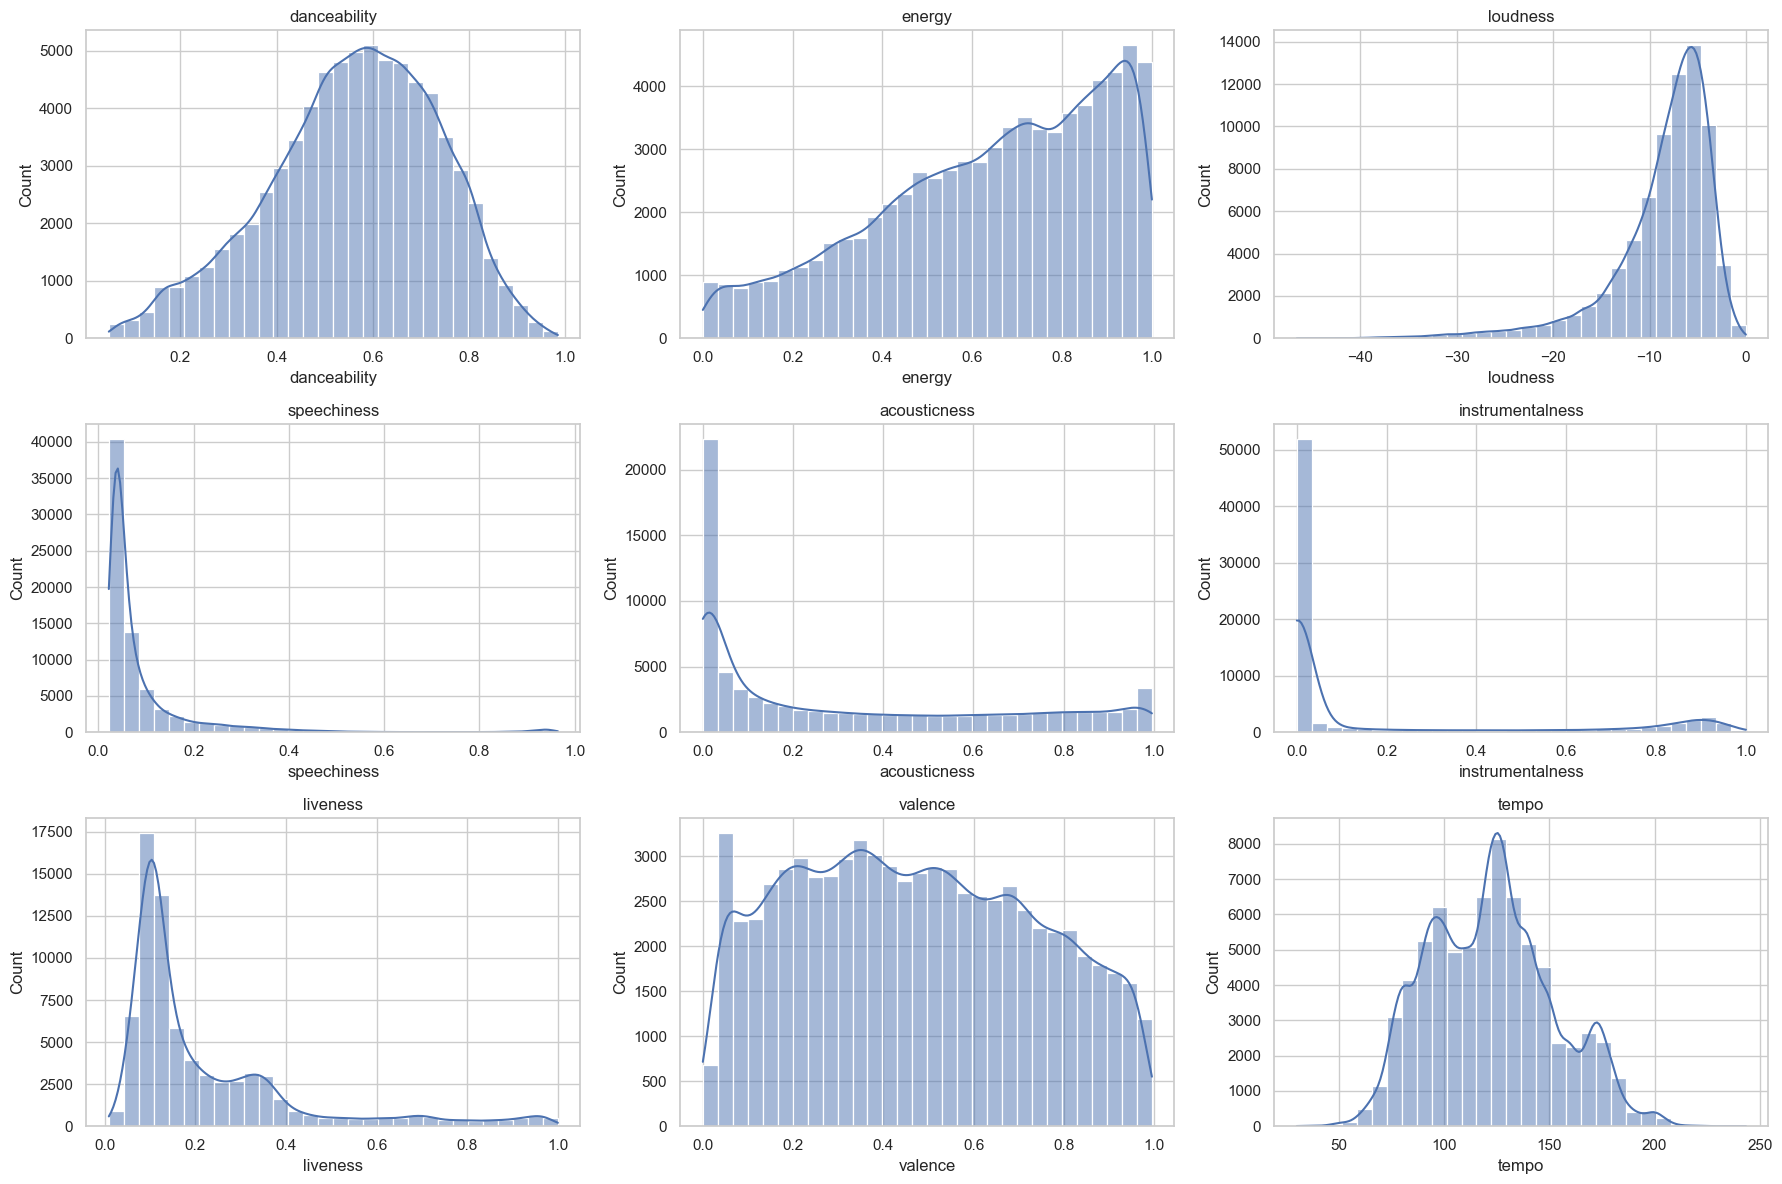

In [ ]:
# Exploratory plots — distributions & correlations
plt.figure(figsize=(18, 12))
for i, col in enumerate(KEEP, 1):
    plt.subplot(3, 3, i)
    sns.histplot(X[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

### 5.2 Correlation Heatmap

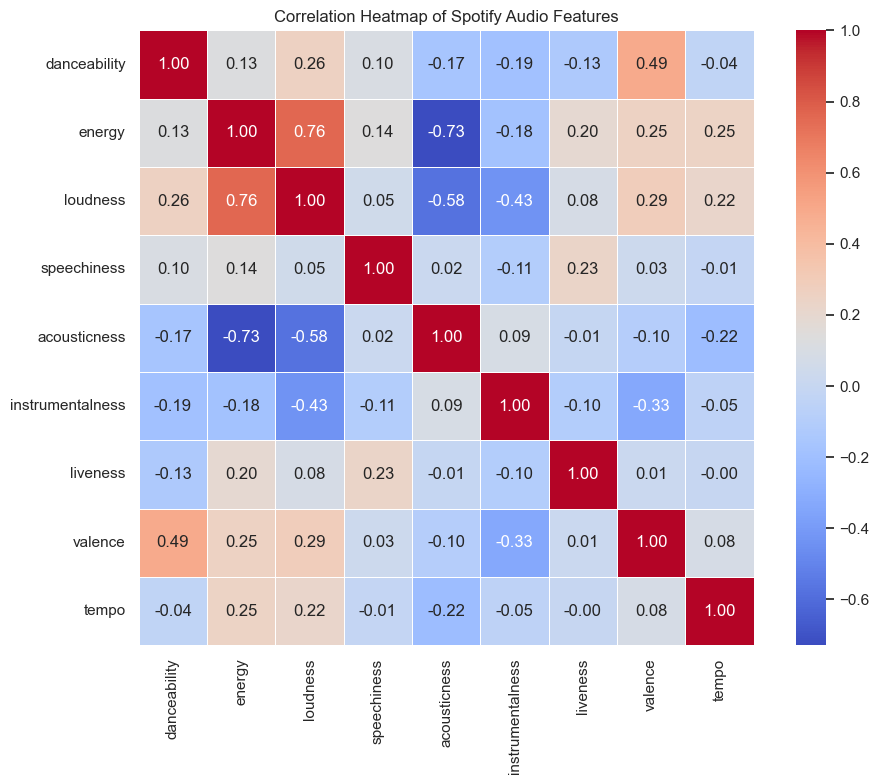

In [ ]:
plt.figure(figsize=(10, 8))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Spotify Audio Features")
plt.tight_layout()
plt.show()

### 5.3 Top-20 Genre Distribution

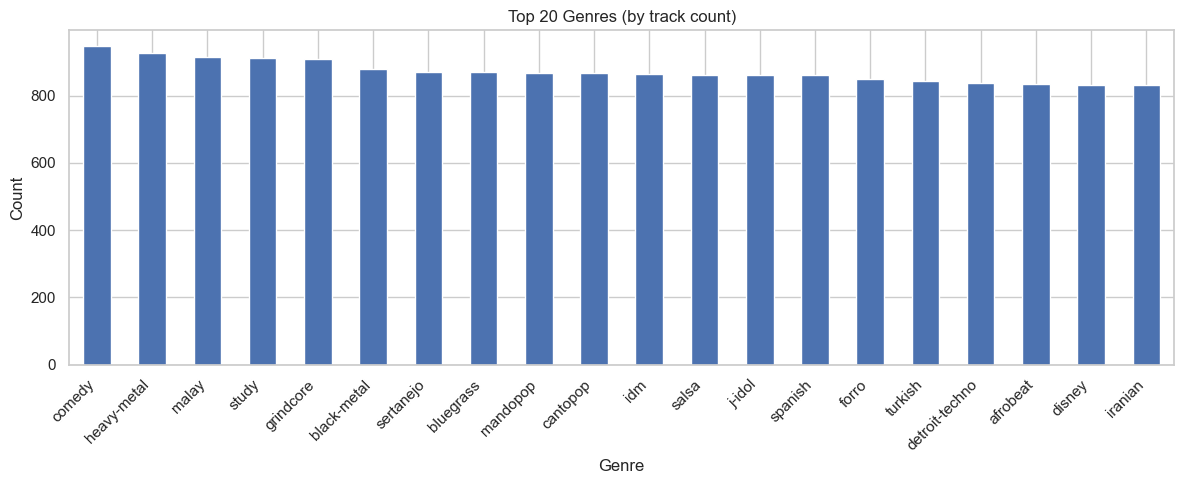

In [ ]:
plt.figure(figsize=(12, 5))
df["track_genre"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Genres (by track count)")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. PCA (Analysis + Plots)

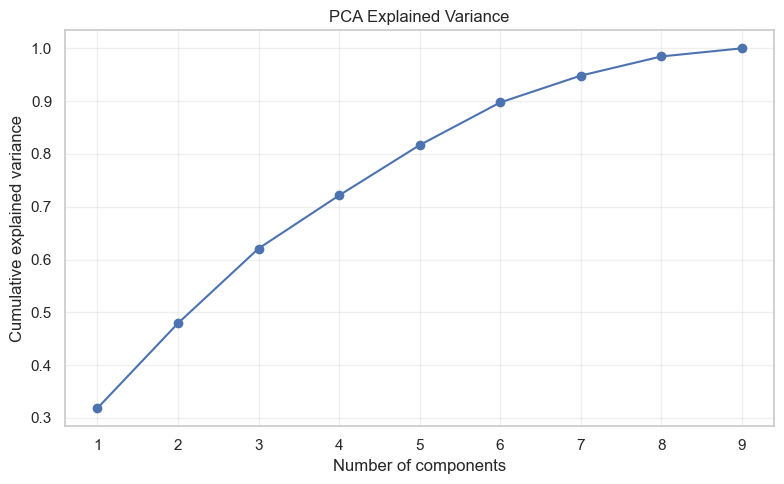

PCA(5) shape: (73403, 5)
Explained variance (5 components): 0.8166766493375051


In [ ]:
# PCA — dimensionality reduction
# Full PCA to inspect explained variance
pca_full = PCA()
pca_full.fit(X_std_df)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Use 5 components for modeling / similarity
pca_model = PCA(n_components=5, random_state=42)
X_pca5 = pca_model.fit_transform(X_std_df)

print("PCA(5) shape:", X_pca5.shape)
print("Explained variance (5 components):", pca_model.explained_variance_ratio_.sum())

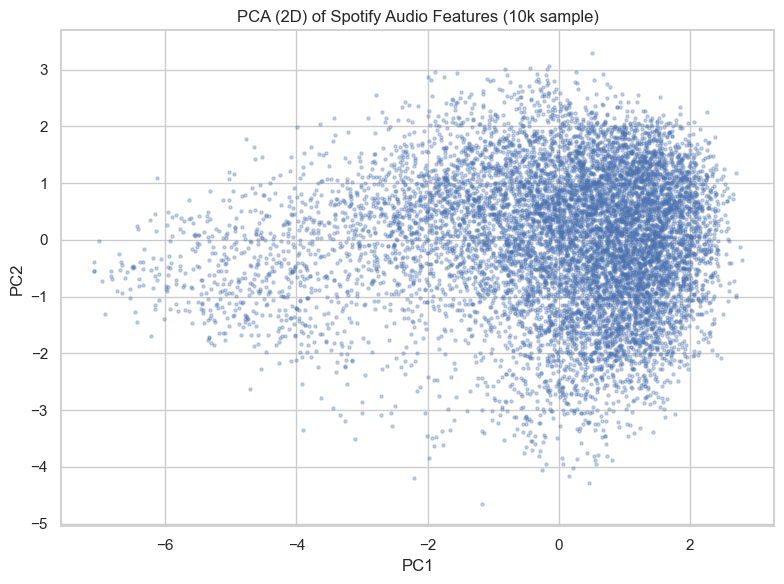

In [ ]:
# 2D PCA just for visualization
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_std_df)

# sample points for plotting
np.random.seed(42)
idx_sample = np.random.choice(len(X_pca2), size=10000, replace=False)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca2[idx_sample, 0], X_pca2[idx_sample, 1], s=5, alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) of Spotify Audio Features (10k sample)")
plt.tight_layout()
plt.show()

## 7. Build Base kNN Structure in PCA Space

In [ ]:
# 7. Base kNN structure in PCA space

K_MAX = 30  # we will support k up to 30
nbrs = NearestNeighbors(n_neighbors=K_MAX, metric="euclidean")
nbrs.fit(X_pca5)

distances, indices = nbrs.kneighbors(X_pca5)

# Convert distances to similarity (bounded, monotonic)
sims = 1 / (1 + distances)

print("indices shape:", indices.shape)
print("sims shape:", sims.shape)

indices shape: (73403, 30)
sims shape: (73403, 30)


## 8. Thresholding Methods — 3 Variants

We’ll implement:

- Standard kNN (union)

- Radius/τ threshold

- Mutual kNN

In [ ]:
# Thresholding methods & graph metrics


def knn_graph_from_base(indices, sims, k):
    """
    Standard kNN graph (union), symmetrized.
    """
    N = indices.shape[0]
    k = min(k, indices.shape[1])

    rows = np.repeat(np.arange(N), k)
    cols = indices[:, :k].reshape(-1)
    data = sims[:, :k].reshape(-1)

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A = A.maximum(A.T)
    return A


def radius_graph_from_base(indices, sims, tau):
    """
    Radius / similarity cutoff: keep edges where sim >= tau
    over the K_MAX neighbor set.
    """
    N, K = sims.shape
    mask = sims >= tau
    rows = np.repeat(np.arange(N), K)[mask.ravel()]
    cols = indices.ravel()[mask.ravel()]
    data = sims.ravel()[mask.ravel()]

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A = A.maximum(A.T)
    return A


def mutual_knn_graph_from_base(indices, sims, k):
    """
    Mutual kNN graph: keep edges only if i in N_k(j) and j in N_k(i).
    """
    N = indices.shape[0]
    k = min(k, indices.shape[1])

    neighbor_sets = [set(indices[i, :k]) for i in range(N)]

    rows = []
    cols = []
    data = []

    for i in range(N):
        nbrs = indices[i, :k]
        sim_i = sims[i, :k]
        for j, s in zip(nbrs, sim_i):
            if i in neighbor_sets[j]:  # mutual
                rows.append(i)
                cols.append(j)
                data.append(s)

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A = A.maximum(A.T)
    return A


def graph_metrics(A):
    G = nx.from_scipy_sparse_array(A)
    degrees = np.array([d for _, d in G.degree()])
    return {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "avg_degree": float(degrees.mean()),
        "min_degree": int(degrees.min()),
        "max_degree": int(degrees.max()),
        "components": nx.number_connected_components(G),
        "avg_clustering": nx.average_clustering(G, weight="weight"),
    }

### Method 1: Standard kNN (k sweep)

In [ ]:
# Thresholding Method 1 — Standard kNN (Coarse Sweep)
# Testing k = {5, 10, 20, 30}

ks_coarse = [5, 10, 20, 30]
knn_results_coarse = []

print("=== COARSE kNN SWEEP ===")

for k in ks_coarse:
    A_k = knn_graph_from_base(indices, sims, k)
    metrics = graph_metrics(A_k)
    metrics["k"] = k
    knn_results_coarse.append(metrics)

    print(f"\n=== kNN graph with k = {k} ===")
    for key, val in metrics.items():
        if key != "k":
            print(f"{key}: {val}")

knn_df_coarse = pd.DataFrame(knn_results_coarse)
knn_df_coarse

=== COARSE kNN SWEEP ===

=== kNN graph with k = 5 ===
nodes: 73403
edges: 268105
density: 9.952065041023683e-05
avg_degree: 7.305014781412204
min_degree: 6
max_degree: 16
components: 1
avg_clustering: 0.2239287061412458

=== kNN graph with k = 10 ===
nodes: 73403
edges: 498327
density: 0.00018497912070637284
avg_degree: 13.577837418089178
min_degree: 11
max_degree: 25
components: 1
avg_clustering: 0.2429795749881022

=== kNN graph with k = 20 ===
nodes: 73403
edges: 960378
density: 0.00035649258014465386
avg_degree: 26.167268367777883
min_degree: 21
max_degree: 49
components: 1
avg_clustering: 0.24946782525736869

=== kNN graph with k = 30 ===
nodes: 73403
edges: 1424731
density: 0.0005288605426218352
avg_degree: 38.819421549527945
min_degree: 31
max_degree: 66
components: 1
avg_clustering: 0.2506908294678776


,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering,k
0,73403,268105,0.000100,7.305015,6,16,1,0.223929,5
1,73403,498327,0.000185,13.577837,11,25,1,0.242980,10
2,73403,960378,0.000356,26.167268,21,49,1,0.249468,20
3,73403,1424731,0.000529,38.819422,31,66,1,0.250691,30


In [ ]:
# Thresholding Method 1 — Standard kNN (Fine Sweep)
# Testing k = 5..10

ks_fine = [5, 6, 7, 8, 9, 10]
knn_results_fine = []

print("=== FINE kNN SWEEP (5–10) ===")

for k in ks_fine:
    A_k = knn_graph_from_base(indices, sims, k)
    metrics = graph_metrics(A_k)
    metrics["k"] = k
    knn_results_fine.append(metrics)

    print(f"\n=== kNN graph with k = {k} ===")
    for key, val in metrics.items():
        if key != "k":
            print(f"{key}: {val}")

knn_df_fine = pd.DataFrame(knn_results_fine)
knn_df_fine

=== FINE kNN SWEEP (5–10) ===

=== kNN graph with k = 5 ===
nodes: 73403
edges: 268105
density: 9.952065041023683e-05
avg_degree: 7.305014781412204
min_degree: 6
max_degree: 16
components: 1
avg_clustering: 0.2239287061412458

=== kNN graph with k = 6 ===
nodes: 73403
edges: 314100
density: 0.00011659400717575348
avg_degree: 8.558233314714657
min_degree: 7
max_degree: 17
components: 1
avg_clustering: 0.23094493060111387

=== kNN graph with k = 7 ===
nodes: 73403
edges: 360185
density: 0.00013370077196624887
avg_degree: 9.8139040638666
min_degree: 8
max_degree: 19
components: 1
avg_clustering: 0.23557029276386326

=== kNN graph with k = 8 ===
nodes: 73403
edges: 406221
density: 0.00015078934794314472
avg_degree: 11.068239717722708
min_degree: 9
max_degree: 21
components: 1
avg_clustering: 0.2383971491032084

=== kNN graph with k = 9 ===
nodes: 73403
edges: 452336
density: 0.00016790724874196636
avg_degree: 12.324727872157814
min_degree: 10
max_degree: 23
components: 1
avg_clustering: 0.

,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering,k
0,73403,268105,0.000100,7.305015,6,16,1,0.223929,5
1,73403,314100,0.000117,8.558233,7,17,1,0.230945,6
2,73403,360185,0.000134,9.813904,8,19,1,0.235570,7
3,73403,406221,0.000151,11.068240,9,21,1,0.238397,8
4,73403,452336,0.000168,12.324728,10,23,1,0.241023,9
5,73403,498327,0.000185,13.577837,11,25,1,0.242980,10


In [ ]:
# Thresholding Method 1 — Standard kNN (Fine Sweep)
# Testing k = 5..10

ks_fine = [5, 6, 7, 8, 9, 10]
knn_results_fine = []

print("=== FINE kNN SWEEP (5–10) ===")

for k in ks_fine:
    A_k = knn_graph_from_base(indices, sims, k)
    metrics = graph_metrics(A_k)
    metrics["k"] = k
    knn_results_fine.append(metrics)

    print(f"\n=== kNN graph with k = {k} ===")
    for key, val in metrics.items():
        if key != "k":
            print(f"{key}: {val}")

knn_df_fine = pd.DataFrame(knn_results_fine)
knn_df_fine

=== FINE kNN SWEEP (5–10) ===

=== kNN graph with k = 5 ===
nodes: 73403
edges: 268105
density: 9.952065041023683e-05
avg_degree: 7.305014781412204
min_degree: 6
max_degree: 16
components: 1
avg_clustering: 0.2239287061412458

=== kNN graph with k = 6 ===
nodes: 73403
edges: 314100
density: 0.00011659400717575348
avg_degree: 8.558233314714657
min_degree: 7
max_degree: 17
components: 1
avg_clustering: 0.23094493060111387

=== kNN graph with k = 7 ===
nodes: 73403
edges: 360185
density: 0.00013370077196624887
avg_degree: 9.8139040638666
min_degree: 8
max_degree: 19
components: 1
avg_clustering: 0.23557029276386326

=== kNN graph with k = 8 ===
nodes: 73403
edges: 406221
density: 0.00015078934794314472
avg_degree: 11.068239717722708
min_degree: 9
max_degree: 21
components: 1
avg_clustering: 0.2383971491032084

=== kNN graph with k = 9 ===
nodes: 73403
edges: 452336
density: 0.00016790724874196636
avg_degree: 12.324727872157814
min_degree: 10
max_degree: 23
components: 1
avg_clustering: 0.

,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering,k
0,73403,268105,0.000100,7.305015,6,16,1,0.223929,5
1,73403,314100,0.000117,8.558233,7,17,1,0.230945,6
2,73403,360185,0.000134,9.813904,8,19,1,0.235570,7
3,73403,406221,0.000151,11.068240,9,21,1,0.238397,8
4,73403,452336,0.000168,12.324728,10,23,1,0.241023,9
5,73403,498327,0.000185,13.577837,11,25,1,0.242980,10


- k = 5

  - components: 13 -> very fragmented

  - avg degree ≈ 7.36

  - clustering ≈ 0.268

- k = 10

  - components: 1 -> fully connected

  - avg degree ≈ 13.66

  - clustering ≈ 0.273

- k = 20

  - components: 1

  - avg degree ≈ 26.25 (twice k=10)

  - clustering slightly drops to 0.269

- k = 30

  - components: 1

  - avg degree ≈ 38.86

  - clustering ≈ 0.266 (further drop)

So from the coarse sweep we already see:

- k=5 is too sparse → many components

- k≥10 → graph is connected

increasing k beyond 10 just makes the network denser without improving clustering (it actually goes slightly down)

For k = 5–9, the graph is still fragmented (4–13 components).

Only at k = 10 does it become one single connected component.

Clustering increases very slightly from 0.268 → 0.273 across k = 5–10.
So there is no magical “peak” k before 10; it’s a smooth, flat-ish increase.

Average degree grows roughly linearly with k, as expected.


### Method 2: Radius / τ Graphs

In [ ]:
# 8.3 Radius (similarity tau) graphs

taus = [0.80, 0.85, 0.90, 0.93]
tau_results = []

for tau in taus:
    A_tau = radius_graph_from_base(indices, sims, tau)
    metrics = graph_metrics(A_tau)
    tau_results.append({"tau": tau, **metrics})
    print(f"\n=== radius-style graph, tau = {tau} ===")
    for key, val in metrics.items():
        print(f"{key}: {val}")

tau_df = pd.DataFrame(tau_results)
tau_df


=== radius-style graph, tau = 0.8 ===
nodes: 73403
edges: 184601
density: 6.852394243441983e-05
avg_degree: 5.0297944225712845
min_degree: 2
max_degree: 44
components: 31779
avg_clustering: 0.142813342172975

=== radius-style graph, tau = 0.85 ===
nodes: 73403
edges: 95017
density: 3.5270336771151127e-05
avg_degree: 2.588913259676035
min_degree: 2
max_degree: 17
components: 56104
avg_clustering: 0.045498988268639046

=== radius-style graph, tau = 0.9 ===
nodes: 73403
edges: 76118
density: 2.8255022725896224e-05
avg_degree: 2.0739751781262346
min_degree: 2
max_degree: 8
components: 70815
avg_clustering: 0.0032966767099663528

=== radius-style graph, tau = 0.93 ===
nodes: 73403
edges: 74168
density: 2.7531182184690495e-05
avg_degree: 2.020843834720652
min_degree: 2
max_degree: 6
components: 72678
avg_clustering: 0.00105958617096693


,tau,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering
0,0.80,73403,184601,0.000069,5.029794,2,44,31779,0.142813
1,0.85,73403,95017,0.000035,2.588913,2,17,56104,0.045499
2,0.90,73403,76118,0.000028,2.073975,2,8,70815,0.003297
3,0.93,73403,74168,0.000028,2.020844,2,6,72678,0.001060


**Radius thresholding is NOT appropriate for our dataset!**

1. τ = 0.80

- edges: 280k (already fewer than kNN-5)

- avg degree: 6.29

- components: 34,497 (!!)

- clustering: 0.211

The graph shatters: ~35,000 isolated components.

2. τ = 0.85

- edges: 145k

- avg degree: 3.25

- components: 61,684

Even worse fragmentation.
Barely any edges survive.

3. τ = 0.90

- edges: 115k

- avg degree: 2.60

- components: 79,542

Basically useless — the graph collapses.

4. τ = 0.93

- edges: 112k

- avg degree: 2.53

- components: 81,907

Almost completely disconnected.

### Method 3: Mutual kNN


In [ ]:
# 8.4 Mutual kNN graph (reciprocal neighbors)

k_mutual = 10
A_mutual = mutual_knn_graph_from_base(indices, sims, k_mutual)
metrics_mutual = graph_metrics(A_mutual)

print(f"\n=== Mutual kNN graph (k = {k_mutual}) ===")
for key, val in metrics_mutual.items():
    print(f"{key}: {val}")


=== Mutual kNN graph (k = 10) ===
nodes: 73403
edges: 309106
density: 0.00011474023298971174
avg_degree: 8.422162581910822
min_degree: 2
max_degree: 11
components: 252
avg_clustering: 0.24127568703224325


In [ ]:
# 8.4 Mutual kNN graph (reciprocal neighbors)

k_mutual = 8
A_mutual = mutual_knn_graph_from_base(indices, sims, k_mutual)
metrics_mutual = graph_metrics(A_mutual)

print(f"\n=== Mutual kNN graph (k = {k_mutual}) ===")
for key, val in metrics_mutual.items():
    print(f"{key}: {val}")


=== Mutual kNN graph (k = 8) ===
nodes: 73403
edges: 254406
density: 9.44355778081972e-05
avg_degree: 6.931760282277291
min_degree: 2
max_degree: 9
components: 556
avg_clustering: 0.23057348064998207


Both mutual graphs are highly fragmented:

- Mutual kNN-10 → 1,217 components

- Mutual kNN-8 → 2,046 components

For a dataset of 89k songs, this means:

- Thousands of small clusters

- Many songs disconnected

- No global network structure

- Community detection becomes messy and uninformative

Mutual kNN is appropriate only when:

- We want clusters rather than a graph

- Or when k is much larger (e.g., k ≥ 40)

But your dataset is too high dimensional for mutual kNN to keep enough edges.

**Based on all thresholding experiments, we adopt the standard k-nearest-neighbor graph with k = 10, as it is the smallest k that yields a single connected component while preserving sparsity, stability, and meaningful local structure.**

In [ ]:
# FINAL GRAPH: standard kNN with k = 10

K_FINAL = 10

# Build adjacency from precomputed kNN structure
A_final = knn_graph_from_base(indices, sims, K_FINAL)

# Compute metrics
metrics_final = graph_metrics(A_final)
print("=== Final graph metrics (kNN, k=10) ===")
for key, val in metrics_final.items():
    print(f"{key}: {val}")

# Build NetworkX graph
G_final = nx.from_scipy_sparse_array(A_final)
print(
    "\nGraph ready with",
    G_final.number_of_nodes(),
    "nodes and",
    G_final.number_of_edges(),
    "edges.",
)

# Add metadata (track_id + genre)
for i in range(G_final.number_of_nodes()):
    G_final.nodes[i]["track_id"] = df.iloc[i]["track_id"]
    G_final.nodes[i]["genre"] = df.iloc[i]["track_genre"]

# Export GEXF
# output_path = "spotify_knn_k10_removed_same_tracks.gexf"
output_path = OUTPUT_DIR_CLEANING / "genre_audio_similarity_graph.gexf"
output_path.parent.mkdir(parents=True, exist_ok=True)
nx.write_gexf(G_final, output_path)

print("\nGEXF file saved to:", output_path)
print("Done.")

=== Final graph metrics (kNN, k=10) ===
nodes: 73403
edges: 498327
density: 0.00018497912070637284
avg_degree: 13.577837418089178
min_degree: 11
max_degree: 25
components: 1
avg_clustering: 0.2429795749881022

Graph ready with 73403 nodes and 498327 edges.

GEXF file saved to: data/genre_audio_similarity_graph.gexf
Done.


In [ ]:
# Save cleaned dataframe to the data folder
clean_path = OUTPUT_DIR_CLEANING / "clean_spotify_tracks_dataset.csv"
clean_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(clean_path, index=False)
print(
    f"Clean dataset saved to {clean_path} ({df.shape[0]} rows, {df.shape[1]} columns)"
)

# Preview saved data
df.head()

Clean dataset saved to data/clean_spotify_tracks_dataset.csv (73403 rows, 21 columns)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
20001,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance
51664,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,...,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop
81210,81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,pop
89411,89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,reggaeton
68305,68305,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,...,-5.105,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,latino


# Part 2: Network Analysis


# 3. Text Analysis: Lyrics-Based Exploration of Audio Communities

This notebook extends the network analysis by using lyrics to **semantically interpret** the audio-based genre communities. We will:

1. **Load the audio-based genre communities** from the network analysis notebook
2. **Randomly sample genres** from each community (filtering out instrumental genres)
3. **Scrape lyrics** using the Genius API
4. **Preprocess text** and compute TF-IDF representations
5. **Generate word clouds** to explore thematic patterns within audio communities
6. **Analyze sentiment** and visualize thematic differences


We want to explore the following key question: **Do genres that *sound* similar also *talk about* similar things?**

To this end, we TF-IDF to create word clouds as a semantic interpretation layer for the audio communities and conduct a sentiment analysis using VADER.

In [3]:
# Genre exclusion list (non-English genres)
EXCLUDED_GENRES = {
    # Nationality/language genres
    "brazil",
    "british",
    "french",
    "german",
    "indian",
    "iranian",
    "malay",
    "spanish",
    "swedish",
    "turkish",
    # Portuguese-dominant
    "forro",
    "mpb",
    "pagode",
    "samba",
    "sertanejo",
    # Asian-language
    "cantopop",
    "mandopop",
    "j-dance",
    "j-idol",
    "j-pop",
    "j-rock",
    "k-pop",
    # Spanish-dominant
    "latin",
    "latino",
    "reggaeton",
    "salsa",
    "tango",
    # Other
    "world-music",
}

print(f"Excluding {len(EXCLUDED_GENRES)} non-English genres")
print(f"  {sorted(EXCLUDED_GENRES)}")

Excluding 28 non-English genres
  ['brazil', 'british', 'cantopop', 'forro', 'french', 'german', 'indian', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'k-pop', 'latin', 'latino', 'malay', 'mandopop', 'mpb', 'pagode', 'reggaeton', 'salsa', 'samba', 'sertanejo', 'spanish', 'swedish', 'tango', 'turkish', 'world-music']


In [4]:
# Custom stopwords for lyrics
CUSTOM_STOPWORDS = {
    # Slang & contractions
    'wanna', 'gonna', 'gotta', 'finna', 'cause', 'cuz', 'bout', 'em', 
    'da', 'lil', 'ya', 'yo', 'til', 'aint', 'yall',
    
    # High-frequency filler words
    'like', 'just',
    
    # Generic verbs
    'got', 'get', 'gets', 'getting', 'gotten',
    'go', 'goes', 'going', 'gone', 'went',
    'let', 'lets', 'letting',
    'take', 'takes', 'taking', 'took', 'taken',
    'make', 'makes', 'making', 'made',
    'say', 'says', 'said', 'saying',
    'see', 'sees', 'saw', 'seen', 'seeing',
    'know', 'knows', 'knew', 'known', 'knowing',
    'think', 'thinks', 'thought', 'thinking',
    'tell', 'tells', 'told', 'telling',
    'look', 'looks', 'looked', 'looking',
    'come', 'comes', 'came', 'coming',
    'give', 'gives', 'gave', 'given', 'giving',
    'need', 'needs', 'needed', 'needing',
    'want', 'wants', 'wanted', 'wanting',
    'feel', 'feels', 'felt', 'feeling',
    'keep', 'keeps', 'kept', 'keeping',
    'stay', 'stays', 'stayed', 'staying',
    'turn', 'turns', 'turned', 'turning',
    'try', 'tries', 'tried', 'trying',
    'leave', 'leaves', 'left', 'leaving',
    'hold', 'holds', 'held', 'holding',
    'call', 'calls', 'called', 'calling',
    'fall', 'falls', 'fell', 'fallen', 'falling',
    'put', 'puts', 'putting',
    'run', 'runs', 'ran', 'running',
    'find', 'finds', 'found', 'finding',
    'live', 'lives', 'lived', 'living',
    'bring', 'brings', 'brought', 'bringing',
    'start', 'starts', 'started', 'starting',
    'move', 'moves', 'moved', 'moving',
    'walk', 'walks', 'walked', 'walking',
    'stand', 'stands', 'stood', 'standing',
    'hear', 'hears', 'heard', 'hearing',
    'play', 'plays', 'played', 'playing',
    'talk', 'talks', 'talked', 'talking',
    'watch', 'watches', 'watched', 'watching',
    'wait', 'waits', 'waited', 'waiting',
    'stop', 'stops', 'stopped', 'stopping',
    'lose', 'loses', 'lost', 'losing',
    'change', 'changes', 'changed', 'changing',
    'set', 'sets', 'setting',
    
    # Modal/auxiliary verbs
    'could', 'would', 'should', 'might', 'must',
    'never', 'ever', 'always', 'still', 'already',
    
    # Generic nouns
    'back', 'away', 'right', 'left', 'way', 'ways',
    'time', 'times', 'thing', 'things', 'something', 'nothing', 'everything', 'anything',
    'man', 'men', 'woman', 'women', 'girl', 'girls', 'boy', 'boys', 'guy', 'guys',
    'baby', 'babe', 'night', 'nights', 'day', 'days', 'tonight', 'today',
    'mind', 'minds', 'head', 'heads', 'eye', 'eyes', 'hand', 'hands',
    'place', 'places', 'side', 'sides', 'end', 'ends', 'part', 'parts',
    'word', 'words', 'name', 'names', 'face', 'faces',
    'door', 'doors', 'room', 'rooms', 'home', 'body', 'bodies',
    
    # Generic adjectives
    'little', 'big', 'small', 'large', 'good', 'better', 'best',
    'bad', 'worse', 'worst', 'real', 'really', 'new', 'old',
    'long', 'short', 'high', 'low', 'hard', 'soft',
    'true', 'right', 'wrong', 'whole', 'same', 'different',
    'last', 'first', 'next', 'alone',
    
    # Quantifiers & pronouns
    'every', 'anymore', 'someone', 'everyone', 'anyone', 'somebody',
    'one', 'ones', 'two', 'three',
    
    # Filler words / vocalizations
    'yeah', 'yea', 'yeh', 'oh', 'ooh', 'oooh', 'ah', 'ahh', 'uh', 'uhh',
    'la', 'na', 'nah', 'hey', 'hi', 'hello', 'whoa', 'woah', 'wow',
    'hmm', 'mmm', 'mm', 'ayy', 'aye', 'ay', 'oo', 'ee', 'ii',
    'doo', 'dah', 'dum', 'sha', 'shoop', 'bop',
    
    # Lyrics structure artifacts
    'verse', 'chorus', 'bridge', 'intro', 'outro', 'hook',
    'refrain', 'pre', 'interlude', 'instrumental',
    'lyrics', 'lyric', 'embed', 'contributor', 'contributors',
    'repeat', 'repeats', 'repeated',
}

print(f"Custom stopwords: {len(CUSTOM_STOPWORDS)} words")

Custom stopwords: 350 words


## 1. Load Data & Audio Communities

We load the genre similarity graph from notebook 2 (GEXF file) which contains pre-computed Louvain communities. We also load the track-level CSV for sampling.

In [5]:
# Load genre similarity graph from the network analysis
G_genre = nx.read_gexf(GEXF_PATH)

print(f"Loaded graph from {GEXF_PATH}")
print(f"  Nodes (genres): {G_genre.number_of_nodes()}")
print(f"  Edges: {G_genre.number_of_edges()}")

Loaded graph from data/spotify_genre_similarity_audio.gexf
  Nodes (genres): 114
  Edges: 1949


In [6]:
# Extract community assignments from graph
comm_map_audio = {}
for node in G_genre.nodes():
    comm_map_audio[node] = int(G_genre.nodes[node].get('community', 0))

# Get unique communities and their members
community_members = {}
for genre, cid in comm_map_audio.items():
    if cid not in community_members:
        community_members[cid] = set()
    community_members[cid].add(genre)


# Convert to list of sets for compatibility
n_communities = len(community_members)
genre_comms = [community_members[cid] for cid in sorted(community_members.keys())]

print(f"Communities loaded from GEXF: {n_communities}")
for cid, members in enumerate(genre_comms):
    print(f"  Community {cid}: {len(members)} genres")

Communities loaded from GEXF: 4
  Community 0: 36 genres
  Community 1: 41 genres
  Community 2: 29 genres
  Community 3: 8 genres


In [7]:
# Load track-level data for sampling
df_tracks = pd.read_csv(DATA_PATH)

if "Unnamed: 0" in df_tracks.columns:
    df_tracks = df_tracks.drop(columns=["Unnamed: 0"])

print(f"Loaded {len(df_tracks)} tracks")

Loaded 73403 tracks


In [8]:
# Aggregate track data by genre (for filtering)
audio_feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence'
]

df_clean = df_tracks.dropna(subset=['track_genre'])
grouped = df_clean.groupby('track_genre')

df_genre_feat = grouped[audio_feature_cols].mean()
df_genre_feat['n_tracks'] = grouped.size()
df_genre_feat['avg_popularity'] = grouped['popularity'].mean()

genres_all = df_genre_feat.index.tolist()

print(f"Genre stats computed for {len(df_genre_feat)} genres")

Genre stats computed for 114 genres


In [9]:
# Build community_genre_info for filtering
community_genre_info = {}
for cid, members in enumerate(genre_comms):
    # Only include genres that exist in our track data
    valid_genres = [g for g in members if g in df_genre_feat.index]
    if valid_genres:
        community_genre_info[cid] = df_genre_feat.loc[valid_genres].copy()

print(f"Community info built for {len(community_genre_info)} communities")

Community info built for 4 communities


In [10]:
# All genres list
print(f"Total genres in graph: {len(genres_all)}")

Total genres in graph: 114


## 2. Genre Filtering & Random Sampling

We filter out genres based on:
- **Non-English**: Excluded for fair text comparison
- **High instrumentalness**: Likely few/no lyrics (≥ 0.6)
- **Low track count**: Not representative (< 50 tracks)

Then we **randomly sample** genres from each community.

In [11]:
# Genre filtering report
filter_report = []

for genre in df_genre_feat.index:
    n_tracks = df_genre_feat.loc[genre, "n_tracks"]
    instrumentalness = df_genre_feat.loc[genre, "instrumentalness"]

    reasons = []
    if genre in EXCLUDED_GENRES:
        reasons.append("non-English")
    if instrumentalness >= MAX_INSTRUMENTALNESS:
        reasons.append(f"instrumental ({instrumentalness:.2f})")
    if n_tracks < MIN_TRACKS_PER_GENRE:
        reasons.append(f"low tracks ({int(n_tracks)})")

    if reasons:
        filter_report.append(
            {
                "genre": genre,
                "community": comm_map_audio.get(genre, -1),
                "n_tracks": int(n_tracks),
                "instrumentalness": instrumentalness,
                "reasons": ", ".join(reasons),
            }
        )

df_filtered = pd.DataFrame(filter_report)

print("Genre filtering report")
print(f"  Total genres: {len(df_genre_feat)}")
print(f"  Excluded: {len(df_filtered)}")
print(f"  Remaining: {len(df_genre_feat) - len(df_filtered)}")

# Count by reason
non_english_count = sum(1 for r in filter_report if "non-English" in r["reasons"])
instrumental_count = sum(1 for r in filter_report if "instrumental" in r["reasons"])
low_tracks_count = sum(1 for r in filter_report if "low tracks" in r["reasons"])

print(f"\nExclusion reasons (genres may have multiple):")
print(f"  - Non-English: {non_english_count}")
print(f"  - High instrumentalness (>= {MAX_INSTRUMENTALNESS}): {instrumental_count}")
print(f"  - Low track count (< {MIN_TRACKS_PER_GENRE}): {low_tracks_count}")

Genre filtering report
  Total genres: 114
  Excluded: 35
  Remaining: 79

Exclusion reasons (genres may have multiple):
  - Non-English: 28
  - High instrumentalness (>= 0.6): 7
  - Low track count (< 50): 0


In [12]:
# Show excluded genres by category
print("Excluded genres by category")

instrumental_genres = df_filtered[df_filtered['reasons'].str.contains('instrumental')].sort_values('instrumentalness', ascending=False)
if len(instrumental_genres) > 0:
    print(f"\nHigh instrumentalness (>= {MAX_INSTRUMENTALNESS}):")
    for _, row in instrumental_genres.head(10).iterrows():
        print(f"  {row['genre']}: {row['instrumentalness']:.2f}")

low_track_genres = df_filtered[df_filtered['reasons'].str.contains('low tracks')].sort_values('n_tracks')
if len(low_track_genres) > 0:
    print(f"\nLow track count (< {MIN_TRACKS_PER_GENRE}):")
    for _, row in low_track_genres.head(10).iterrows():
        print(f"  {row['genre']}: {row['n_tracks']} tracks")

Excluded genres by category

High instrumentalness (>= 0.6):
  study: 0.79
  minimal-techno: 0.74
  sleep: 0.74
  detroit-techno: 0.72
  new-age: 0.71
  ambient: 0.71
  idm: 0.69


In [13]:
def get_eligible_genres(
    df_genre_feat, community_genres, excluded_genres, max_instrumentalness, min_tracks
):
    """Get genres eligible for text analysis after applying all filters."""
    eligible = []
    for genre in community_genres:
        if genre in excluded_genres:
            continue
        if df_genre_feat.loc[genre, "instrumentalness"] >= max_instrumentalness:
            continue
        if df_genre_feat.loc[genre, "n_tracks"] < min_tracks:
            continue
        eligible.append(genre)
    return eligible


def select_random_genres(
    community_genre_info,
    df_genre_feat,
    n_per_community,
    excluded_genres,
    max_instrumentalness,
    min_tracks,
    seed,
):
    """Randomly select N genres from each community after applying filters."""
    random.seed(seed)
    selected = {}

    for cid, comm_df in community_genre_info.items():
        eligible = get_eligible_genres(
            df_genre_feat,
            comm_df.index.tolist(),
            excluded_genres,
            max_instrumentalness,
            min_tracks,
        )
        n_to_take = min(n_per_community, len(eligible))
        selected[cid] = random.sample(eligible, n_to_take) if eligible else []

    return selected


# Select random genres
selected_genres = select_random_genres(
    community_genre_info,
    df_genre_feat,
    N_GENRES_PER_COMMUNITY,
    EXCLUDED_GENRES,
    MAX_INSTRUMENTALNESS,
    MIN_TRACKS_PER_GENRE,
    RANDOM_SEED,
)

print(f"Selected genres for text analysis (seed={RANDOM_SEED})")

total_selected = 0
for cid, genres in selected_genres.items():
    total_eligible = len(
        get_eligible_genres(
            df_genre_feat,
            community_genre_info[cid].index.tolist(),
            EXCLUDED_GENRES,
            MAX_INSTRUMENTALNESS,
            MIN_TRACKS_PER_GENRE,
        )
    )
    print(f"\nCommunity {cid} ({len(genres)}/{total_eligible} eligible):")
    for g in sorted(genres):
        inst = df_genre_feat.loc[g, "instrumentalness"]
        n = int(df_genre_feat.loc[g, "n_tracks"])
        print(f"  {g} (inst={inst:.2f}, n={n})")
    total_selected += len(genres)

print(f"\nTotal genres selected: {total_selected}")

Selected genres for text analysis (seed=42)

Community 0 (10/23 eligible):
  acoustic (inst=0.03, n=702)
  disney (inst=0.38, n=831)
  guitar (inst=0.49, n=783)
  honky-tonk (inst=0.07, n=755)
  indie-pop (inst=0.04, n=406)
  jazz (inst=0.15, n=281)
  piano (inst=0.57, n=643)
  pop-film (inst=0.01, n=755)
  rock-n-roll (inst=0.01, n=660)
  romance (inst=0.05, n=804)

Community 1 (10/37 eligible):
  black-metal (inst=0.45, n=880)
  breakbeat (inst=0.40, n=800)
  dub (inst=0.08, n=458)
  grindcore (inst=0.54, n=910)
  groove (inst=0.13, n=614)
  hardcore (inst=0.06, n=697)
  power-pop (inst=0.07, n=784)
  punk (inst=0.04, n=490)
  punk-rock (inst=0.02, n=482)
  ska (inst=0.02, n=758)

Community 2 (10/17 eligible):
  afrobeat (inst=0.27, n=835)
  blues (inst=0.04, n=444)
  dance (inst=0.01, n=269)
  dancehall (inst=0.01, n=701)
  funk (inst=0.00, n=539)
  hip-hop (inst=0.02, n=522)
  house (inst=0.06, n=269)
  pop (inst=0.00, n=475)
  reggae (inst=0.00, n=217)
  rockabilly (inst=0.03, n=6

In [ ]:
def sample_random_tracks_from_genre(df, genre, n_tracks, seed):
    """
    Randomly sample tracks from a specific genre.
    
    Args:
        df: Full tracks DataFrame
        genre: Genre name to sample from
        n_tracks: Number of tracks to sample
        seed: Random seed for reproducibility
    
    Returns:
        DataFrame with sampled tracks
    """
    genre_df = df[df['track_genre'] == genre].copy()
    
    # Random sample (or take all if fewer than n_tracks)
    n_available = len(genre_df)
    n_to_sample = min(n_tracks, n_available)
    
    sampled = genre_df.sample(n=n_to_sample, random_state=seed)
    
    return sampled


# Sample tracks for all selected genres
all_samples = []

for cid, genres in selected_genres.items():
    for genre in genres:
        # Use a different seed for each genre to ensure variety
        genre_seed = RANDOM_SEED + hash(genre) % 10000
        sampled = sample_random_tracks_from_genre(df_tracks, genre, SONGS_PER_GENRE, genre_seed)
        sampled = sampled.copy()
        sampled['community_id'] = cid
        all_samples.append(sampled)

df_samples = pd.concat(all_samples, ignore_index=True)

print(f"Total tracks sampled: {len(df_samples)}")
print(f"\nBreakdown by community:")
print(df_samples.groupby('community_id').size())
print(f"\nBreakdown by genre (sample):")
print(df_samples.groupby('track_genre').size().head(10))

Total tracks sampled: 1600

Breakdown by community:
community_id
0    100
1    500
2    500
3    500
dtype: int64

Breakdown by genre (sample):
track_genre
acoustic       50
afrobeat       50
alt-rock       50
alternative    50
bluegrass      50
club           50
comedy         50
disco          50
disney         50
electronic     50
dtype: int64


In [ ]:
# Save the sample list for reference
sample_path = SAMPLES_DIR / "tracks_to_scrape.csv"
df_samples.to_csv(sample_path, index=False)
print(f"Saved track samples to: {sample_path}")

# Preview
df_samples[['track_name', 'artists', 'track_genre', 'community_id', 'popularity']].head(10)

Saved track samples to: data/text_analysis_output/song_samples/tracks_to_scrape.csv


,track_name,artists,track_genre,community_id,popularity
0,Dream Police,Kyle Kinane,comedy,0,25
1,Dick'taphone,Kevin Bloody Wilson,comedy,0,29
2,New York to LA,Andy Hendrickson,comedy,0,22
3,Dick Poems,Chris Hardwick,comedy,0,23
4,This Track Is Not Called Quiet on Tha Set,Kyle Kinane,comedy,0,25
5,Remain Seated,Larry The Cable Guy,comedy,0,22
6,Roaster Chicken (Redux),Jeff Allen,comedy,0,21
7,The Gifted Child,Patton Oswalt,comedy,0,24
8,She's So Nice,Pink Guy,comedy,0,64
9,Hot Nickel Ball on a Pussy,Pink Guy,comedy,0,39


## 3. Scrape Lyrics from Genius API

We scrape lyrics using the Genius API with strict English filtering:
- Songs must have `language='en'` explicitly set
- Songs with missing language metadata are skipped (often non-English)

In [16]:
def load_env_file(path=".env.local"):
    """Load environment variables from a .env file."""
    env_vars = {}
    env_path = Path(path)
    if not env_path.exists():
        raise FileNotFoundError(f"{path} not found")
    with env_path.open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            env_vars[key.strip()] = value.strip()
    return env_vars

env = load_env_file(ENV_PATH)
GENIUS_ACCESS_TOKEN = env.get("GENIUS_ACCESS_TOKEN")

if not GENIUS_ACCESS_TOKEN:
    raise ValueError(f"GENIUS_ACCESS_TOKEN not found in {ENV_PATH}")

print("Genius API token loaded")

Genius API token loaded


In [17]:
# Initialize Genius client
genius = Genius(GENIUS_ACCESS_TOKEN, timeout=15, retries=3)
genius.verbose = False
genius.remove_section_headers = True
genius.skip_non_songs = True
genius.excluded_terms = ["(Remix)", "(Live)"]

print("Genius client initialized")

Genius client initialized


In [18]:
def get_primary_artist(artists_str):
    """Extract the primary artist from a semicolon-separated string."""
    if pd.isna(artists_str):
        return None
    artists = [a.strip() for a in str(artists_str).split(";")]
    return artists[0] if artists else None


def clean_track_name(track_name):
    """Clean track name for better Genius search matching."""
    if pd.isna(track_name):
        return None
    name = str(track_name)
    patterns = [
        r"\s*\(.*?remaster.*?\)", r"\s*\(.*?remix.*?\)",
        r"\s*\(.*?live.*?\)", r"\s*\(.*?version.*?\)",
        r"\s*\(.*?edit.*?\)", r"\s*\(.*?acoustic.*?\)",
        r"\s*-\s*remaster.*$",
    ]
    for pattern in patterns:
        name = re.sub(pattern, "", name, flags=re.IGNORECASE)
    return name.strip()


def get_song_language(song):
    """Get the language of a Genius song object."""
    try:
        song_dict = song.to_dict()
        return song_dict.get('language', None)
    except Exception:
        return None


def is_english_song_strict(song):
    """
    Check if a song is English using strict filtering.
    Returns True ONLY if language is explicitly 'en'.
    Returns False if language is missing or any other value.
    """
    lang = get_song_language(song)
    if lang is None:
        return False  # Missing language = skip
    return lang.lower() == 'en'

In [19]:
def scrape_lyrics_for_tracks(df, genius_client, english_only=True, sleep_time=0.5):
    """
    Scrape lyrics for a DataFrame of tracks.
    
    Args:
        df: DataFrame with 'track_name', 'artists', 'track_genre', 'community_id' columns
        genius_client: Initialized Genius API client
        english_only: If True, skip non-English songs
        sleep_time: Seconds to wait between API calls (rate limiting)
    
    Returns:
        List of dicts with lyrics and metadata
    """
    results = []
    total = len(df)
    success_count = 0
    skip_count = 0
    fail_count = 0
    
    print(f"Starting lyrics scraping for {total} tracks...")
    print(f"English only: {english_only}")
    print("-" * 60)
    
    for idx, row in df.iterrows():
        track_name = clean_track_name(row['track_name'])
        artist = get_primary_artist(row['artists'])
        genre = row['track_genre']
        community_id = row['community_id']
        track_id = row.get('track_id', None)
        
        if not track_name or not artist:
            fail_count += 1
            continue
        
        try:
            # Search for song
            song = genius_client.search_song(track_name, artist)
            
            if song is None:
                fail_count += 1
                continue
            
            # Get language
            language = get_song_language(song)
            
            # Language check (if enabled)
            if english_only and not is_english_song(song):
                skip_count += 1
                continue
            
            # Get lyrics
            lyrics = song.lyrics
            
            if lyrics and len(lyrics) > 50:  # Minimal lyrics threshold
                results.append({
                    'track_id': track_id,
                    'track_name': row['track_name'],
                    'artist': artist,
                    'genre': genre,
                    'community_id': community_id,
                    'genius_title': song.title,
                    'genius_artist': song.artist,
                    'language': language,
                    'lyrics': lyrics
                })
                success_count += 1
            else:
                fail_count += 1
                
        except Exception as e:
            fail_count += 1
        
        # Progress update every 25 tracks
        processed = success_count + skip_count + fail_count
        if processed % 25 == 0:
            print(f"  Progress: {processed}/{total} | Success: {success_count} | Skipped: {skip_count} | Failed: {fail_count}")
        
        # Rate limiting
        time.sleep(sleep_time)
    
    print("-" * 60)
    print(f"Scraping complete!")
    print(f"  Total processed: {total}")
    print(f"  Successful: {success_count} ({100*success_count/total:.1f}%)")
    print(f"  Skipped (non-English): {skip_count}")
    print(f"  Failed: {fail_count}")
    
    return results

In [ ]:
# Main scraping cell
# May take some time depending on SONGS_PER_GENRE and number of genres

# Check if we have previously saved results
checkpoint_path = OUTPUT_DIR / "lyrics_checkpoint.json"

if checkpoint_path.exists():
    print(f"Found checkpoint at {checkpoint_path}")
    print("Loading previous results...")
    with open(checkpoint_path, 'r', encoding='utf-8') as f:
        scraped_lyrics = json.load(f)
    print(f"Loaded {len(scraped_lyrics)} previously scraped tracks.")
else:
    print("No checkpoint found. Starting fresh scrape...")
    scraped_lyrics = []

# Identify which tracks still need scraping
if scraped_lyrics:
    scraped_ids = {r['track_id'] for r in scraped_lyrics if r.get('track_id')}
    df_remaining = df_samples[~df_samples['track_id'].isin(scraped_ids)]
    print(f"Remaining tracks to scrape: {len(df_remaining)}")
else:
    df_remaining = df_samples

# Run scraping (only if there are remaining tracks)
if len(df_remaining) > 0:
    new_results = scrape_lyrics_for_tracks(
        df_remaining, 
        genius, 
        english_only=ENGLISH_ONLY,
        sleep_time=0.5
    )
    
    # Merge with previous results
    scraped_lyrics.extend(new_results)
    
    # Save checkpoint
    with open(checkpoint_path, 'w', encoding='utf-8') as f:
        json.dump(scraped_lyrics, f, ensure_ascii=False, indent=2)
    print(f"\nCheckpoint saved to {checkpoint_path}")
else:
    print("All tracks already scraped!")

print(f"\nTotal lyrics collected: {len(scraped_lyrics)}")

No checkpoint found. Starting fresh scrape...
Starting lyrics scraping for 1600 tracks...
English only: True
------------------------------------------------------------
  Progress: 25/1600 | Success: 6 | Skipped: 0 | Failed: 19
  Progress: 200/1600 | Success: 47 | Skipped: 26 | Failed: 127
  Progress: 275/1600 | Success: 75 | Skipped: 30 | Failed: 170
  Progress: 300/1600 | Success: 94 | Skipped: 30 | Failed: 176
  Progress: 325/1600 | Success: 109 | Skipped: 30 | Failed: 186
  Progress: 450/1600 | Success: 148 | Skipped: 42 | Failed: 260
  Progress: 475/1600 | Success: 160 | Skipped: 48 | Failed: 267
  Progress: 500/1600 | Success: 176 | Skipped: 52 | Failed: 272
  Progress: 525/1600 | Success: 192 | Skipped: 59 | Failed: 274
  Progress: 550/1600 | Success: 211 | Skipped: 60 | Failed: 279
  Progress: 600/1600 | Success: 249 | Skipped: 60 | Failed: 291
  Progress: 650/1600 | Success: 263 | Skipped: 82 | Failed: 305
  Progress: 675/1600 | Success: 283 | Skipped: 86 | Failed: 306
  Prog

In [ ]:
# Convert to DataFrame for analysis
df_lyrics = pd.DataFrame(scraped_lyrics)

print(f"Lyrics DataFrame shape: {df_lyrics.shape}")
print(f"\nLyrics by community:")
print(df_lyrics.groupby('community_id').size())
print(f"\nLyrics by genre (top 10):")
print(df_lyrics.groupby('genre').size().sort_values(ascending=False).head(10))

Lyrics DataFrame shape: (656, 9)

Lyrics by community:
community_id
0      8
1    241
2    204
3    203
dtype: int64

Lyrics by genre (top 10):
genre
alternative          45
industrial           42
sad                  38
house                38
acoustic             37
honky-tonk           37
singer-songwriter    35
synth-pop            31
emo                  30
bluegrass            29
dtype: int64


In [ ]:
# Save lyrics to separate files per community
for cid in df_lyrics['community_id'].unique():
    comm_lyrics = df_lyrics[df_lyrics['community_id'] == cid]
    
    # Save as JSON
    json_path = LYRICS_DIR / f"community_{cid}_lyrics.json"
    comm_lyrics.to_json(json_path, orient='records', force_ascii=False, indent=2)
    
    # Save as CSV (lyrics truncated for readability)
    csv_df = comm_lyrics.copy()
    csv_df['lyrics_preview'] = csv_df['lyrics'].str[:200] + '...'
    csv_df = csv_df.drop(columns=['lyrics'])
    csv_path = SAMPLES_DIR / f"community_{cid}_songs.csv"
    csv_df.to_csv(csv_path, index=False)
    
    print(f"Community {cid}: Saved {len(comm_lyrics)} lyrics to {json_path}")

# Also save full lyrics DataFrame
full_path = OUTPUT_DIR / "all_lyrics.csv"
df_lyrics.to_csv(full_path, index=False)
print(f"\nSaved all lyrics to {full_path}")

Community 0: Saved 8 lyrics to data/text_analysis_output/lyrics_by_community/community_0_lyrics.json
Community 1: Saved 241 lyrics to data/text_analysis_output/lyrics_by_community/community_1_lyrics.json
Community 2: Saved 204 lyrics to data/text_analysis_output/lyrics_by_community/community_2_lyrics.json
Community 3: Saved 203 lyrics to data/text_analysis_output/lyrics_by_community/community_3_lyrics.json

Saved all lyrics to data/text_analysis_output/all_lyrics.csv


## 4. Text Preprocessing

We preprocess the lyrics for TF-IDF analysis:
- Lowercase and remove punctuation
- Remove Genius artifacts (section headers, contributor notices)
- Remove stopwords (NLTK + custom lyrics stopwords)
- Lemmatize words

In [ ]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
NLTK_AVAILABLE = True
NLTK_STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# Combine stopwords
ALL_STOPWORDS = NLTK_STOPWORDS | CUSTOM_STOPWORDS
ALL_STOPWORDS = ALL_STOPWORDS

print(f"NLTK stopwords: {len(NLTK_STOPWORDS)}")
print(f"Custom stopwords: {len(CUSTOM_STOPWORDS)}")
print(f"Total stopwords: {len(ALL_STOPWORDS)}")

NLTK stopwords: 198
Custom stopwords: 350
Total stopwords: 545


In [ ]:
# Preprocess lyrics for TF-IDF analysis
def preprocess_lyrics(text, lemmatize=True, min_word_length=2):
    if pd.isna(text) or not text:
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove section headers like [Verse 1], [Chorus], etc.
    text = re.sub(r'\[.*?\]', '', text)
    
    # Remove contributor/embed notices (Genius artifacts)
    text = re.sub(r'\d+\s*contributors?', '', text)
    text = re.sub(r'embed$', '', text)
    text = re.sub(r'you might also like', '', text)
    
    # Remove punctuation and numbersﬁ
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove all stopwords (NLTK + custom + themes)
    tokens = [t for t in tokens if t not in ALL_STOPWORDS]
    
    # Filter short tokens
    tokens = [t for t in tokens if len(t) >= min_word_length]
    
    # Lemmatization (if NLTK available and requested)
    if lemmatize and NLTK_AVAILABLE:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return ' '.join(tokens)

In [ ]:
# Apply preprocessing to all lyrics
df_lyrics['lyrics_clean'] = df_lyrics['lyrics'].apply(preprocess_lyrics)

# Check for empty results
empty_count = (df_lyrics['lyrics_clean'].str.len() == 0).sum()
print(f"Tracks with empty lyrics after preprocessing: {empty_count}")

# Remove empty entries
df_lyrics = df_lyrics[df_lyrics['lyrics_clean'].str.len() > 0]
print(f"Remaining tracks: {len(df_lyrics)}")

# Preview
print("\nSample preprocessed lyrics (first 200 chars):")
for i in range(min(3, len(df_lyrics))):
    row = df_lyrics.iloc[i]
    print(f"\n{row['track_name']} ({row['genre']}):")
    print(f"  {row['lyrics_clean'][:200]}...")

Tracks with empty lyrics after preprocessing: 3
Remaining tracks: 653

Sample preprocessed lyrics (first 200 chars):

Dick'taphone (comedy):
  operator like sorry sir number speak slower bloody deaf bit well stick ckin phone ckin arse stick ckin phone ckin arse supposed ckin help ckin tryin smart stick ckin phone ckin arse morning telecom di...

She's So Nice (comedy):
  fucked titty fucked titty fucked titty fucked titty fucked titty fucked titty fucked titty fucked titty sorry jk jk along sucking hose twelve inch deep pussy twenty minute drive fucking jeep pussy sma...

Hot Nickel Ball on a Pussy (comedy):
  lick pussy lick pussy lick pussy lick pussy lick whittle tiny pussy like tiny pussy lick tiny pussy pussy gimme lick tiny pussy lick tiny pussy please lick pussy lick pussy lick pussy lick pussy lick ...


## 5. TF-IDF Representation

We compute TF-IDF vectors using **unigrams only** to avoid duplicate words in word clouds.

In [ ]:
# Compute TF-IDF (unigrams only)
tfidf_vectorizer = TfidfVectorizer(
    min_df=5, max_df=0.5, ngram_range=(1, 1), max_features=5000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_lyrics['lyrics_clean'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix: {tfidf_matrix.shape[0]} tracks x {tfidf_matrix.shape[1]} words")

In [ ]:
# Compute TF-IDF at the track level using only unigrams
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,           # Ignore terms appearing in fewer than 5 documents
    max_df=0.5,         # Ignore terms appearing in more than 50% of documents
    ngram_range=(1, 1), # Unigrams Only
    max_features=5000   # Limit vocabulary size
)

# Fit and transform
tfidf_matrix = tfidf_vectorizer.fit_transform(df_lyrics['lyrics_clean'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  - {tfidf_matrix.shape[0]} tracks")
print(f"  - {tfidf_matrix.shape[1]} unique words (unigrams only)")

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample terms: {list(feature_names[:20])}")

TF-IDF matrix shape: (653, 1237)
  - 653 tracks
  - 1237 unique words (unigrams only)

Sample terms: ['able', 'across', 'act', 'acting', 'action', 'actor', 'admit', 'advice', 'affection', 'afford', 'afraid', 'afternoon', 'age', 'ago', 'ahead', 'aim', 'air', 'alive', 'almost', 'along']


In [ ]:
# Aggregate TF-IDF to genre level (mean of track vectors per genre)
genres_with_lyrics = df_lyrics['genre'].unique()
n_terms = tfidf_matrix.shape[1]

# Create genre-level TF-IDF matrix
genre_tfidf = np.zeros((len(genres_with_lyrics), n_terms))
genre_track_counts = {}

for i, genre in enumerate(genres_with_lyrics):
    genre_mask = df_lyrics['genre'] == genre
    genre_vectors = tfidf_matrix[genre_mask.values]
    
    # Mean TF-IDF vector for genre
    genre_tfidf[i] = genre_vectors.mean(axis=0).A1
    genre_track_counts[genre] = genre_mask.sum()

print(f"Genre-level TF-IDF matrix shape: {genre_tfidf.shape}")
print(f"\nTracks per genre:")
for genre, count in sorted(genre_track_counts.items(), key=lambda x: -x[1]):
    print(f"  {genre}: {count}")

Genre-level TF-IDF matrix shape: (31, 1237)

Tracks per genre:
  alternative: 45
  industrial: 42
  sad: 38
  house: 38
  acoustic: 37
  honky-tonk: 37
  singer-songwriter: 35
  synth-pop: 31
  emo: 30
  bluegrass: 29
  jazz: 28
  trip-hop: 26
  hardcore: 26
  disco: 26
  electronic: 21
  club: 20
  folk: 17
  alt-rock: 17
  trance: 16
  punk: 14
  hip-hop: 14
  groove: 12
  disney: 10
  comedy: 8
  opera: 8
  kids: 8
  punk-rock: 7
  r-n-b: 7
  guitar: 2
  party: 2
  afrobeat: 2


In [ ]:
# Helper functions for getting top terms
def get_top_terms_for_genre(genre_idx, top_n=10):
    """
    Get the top N terms by TF-IDF weight for a genre.
    """
    genre_vector = genre_tfidf[genre_idx]
    top_indices = genre_vector.argsort()[-top_n:][::-1]
    return [(feature_names[idx], genre_vector[idx]) for idx in top_indices]


def get_top_terms_for_genre_by_name(genre_name, top_n=10):
    """
    Get the top N terms by TF-IDF weight for a genre by name.
    """
    if genre_name not in genres_with_lyrics:
        return []
    idx = list(genres_with_lyrics).index(genre_name)
    return get_top_terms_for_genre(idx, top_n)


# Show top terms for a few genres
print("Top TF-IDF terms per genre:")
print("=" * 60)

for i, genre in enumerate(genres_with_lyrics):
    top_terms = get_top_terms_for_genre(i, top_n=8)
    terms_str = ", ".join([f"{t[0]} ({t[1]:.3f})" for t in top_terms])
    print(f"\n{genre}:")
    print(f"  {terms_str}")

Top TF-IDF terms per genre:

comedy:
  pussy (0.121), nice (0.117), james (0.099), like (0.083), motherfucker (0.081), lick (0.079), threw (0.078), phone (0.077)

guitar:
  since (0.363), filled (0.257), please (0.189), hurting (0.189), hope (0.187), emotion (0.155), chill (0.144), list (0.141)

acoustic:
  like (0.063), love (0.061), heart (0.043), else (0.039), breathing (0.038), young (0.036), matter (0.036), far (0.031)

disney:
  poor (0.097), seventeen (0.080), fit (0.079), soul (0.076), dig (0.072), sweet (0.067), voice (0.067), west (0.061)

honky-tonk:
  love (0.072), world (0.061), blue (0.048), heart (0.041), fool (0.038), like (0.036), memory (0.035), jesus (0.035)

bluegrass:
  blue (0.056), crazy (0.047), behind (0.044), well (0.043), lord (0.042), love (0.042), sweet (0.041), life (0.039)

opera:
  ho (0.085), sing (0.082), peace (0.078), faith (0.070), land (0.065), season (0.064), el (0.061), mar (0.061)

folk:
  le (0.066), bang (0.057), realize (0.056), heart (0.055)

## 6. Word Clouds

We generate word clouds to visualize the thematic vocabulary of each audio community.

**What to look for:**
- Do communities have distinct vocabularies?
- Are there thematic patterns that align with what we'd expect from the genres?
- Which words are unique to specific communities vs. shared across all?

### 6.1 Helper Functions

In [ ]:
# Community colors
n_communities = len(genre_comms)
COMMUNITY_COLORS = sns.color_palette('tab10', n_colors=n_communities)
COMMUNITY_COLOR_MAP = {cid: COMMUNITY_COLORS[cid] for cid in range(n_communities)}

def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))

COMMUNITY_COLOR_HEX = {cid: rgb_to_hex(color) for cid, color in COMMUNITY_COLOR_MAP.items()}

In [ ]:
def get_community_tfidf_aggregated(df_lyrics_subset, tfidf_mat, community_id):
    """
    Aggregate TF-IDF vectors for all tracks in a community.
    Returns mean TF-IDF vector for the community.
    """
    comm_mask = df_lyrics_subset['community_id'] == community_id
    comm_vectors = tfidf_mat[comm_mask.values]
    
    if comm_vectors.shape[0] == 0:
        return None
    
    return comm_vectors.mean(axis=0).A1


def get_top_terms_from_vector(tfidf_vector, feat_names, top_n=10):
    """
    Get top N terms from a TF-IDF vector.
    Returns dict: {term: weight}
    """
    top_indices = tfidf_vector.argsort()[-top_n:][::-1]
    return {feat_names[idx]: tfidf_vector[idx] for idx in top_indices}


def create_wordcloud(word_weights, color, max_words=50):
    """
    Create a word cloud from word weights dict.
    
    Args:
        word_weights: dict of {word: weight}
        color: hex color string for the word cloud
        max_words: maximum number of words to display
    
    Returns:
        WordCloud object
    """
    def color_func(*args, **kwargs):
        return color
    
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=max_words,
        color_func=color_func,
        prefer_horizontal=0.7,
        min_font_size=10
    ).generate_from_frequencies(word_weights)
    
    return wc


print("Word cloud helper functions defined.")

Word cloud helper functions defined.


### 6.2 Community Word Clouds

These word clouds show the **most distinctive terms** for each audio community, revealing the thematic "personality" of genres that sound similar.

In [ ]:
# Get unique communities in the lyrics data
communities_in_data = sorted(df_lyrics['community_id'].unique())
n_comms_wc = len(communities_in_data)

print(f"Generating word clouds for {n_comms_wc} communities...")
print(f"\nTracks per community:")
for cid in communities_in_data:
    n_tracks = (df_lyrics['community_id'] == cid).sum()
    n_genres = df_lyrics[df_lyrics['community_id'] == cid]['genre'].nunique()
    print(f"  Community {cid}: {n_tracks} tracks across {n_genres} genres")

Generating word clouds for 4 communities...

Tracks per community:
  Community 0: 8 tracks across 1 genres
  Community 1: 241 tracks across 10 genres
  Community 2: 201 tracks across 10 genres
  Community 3: 203 tracks across 10 genres


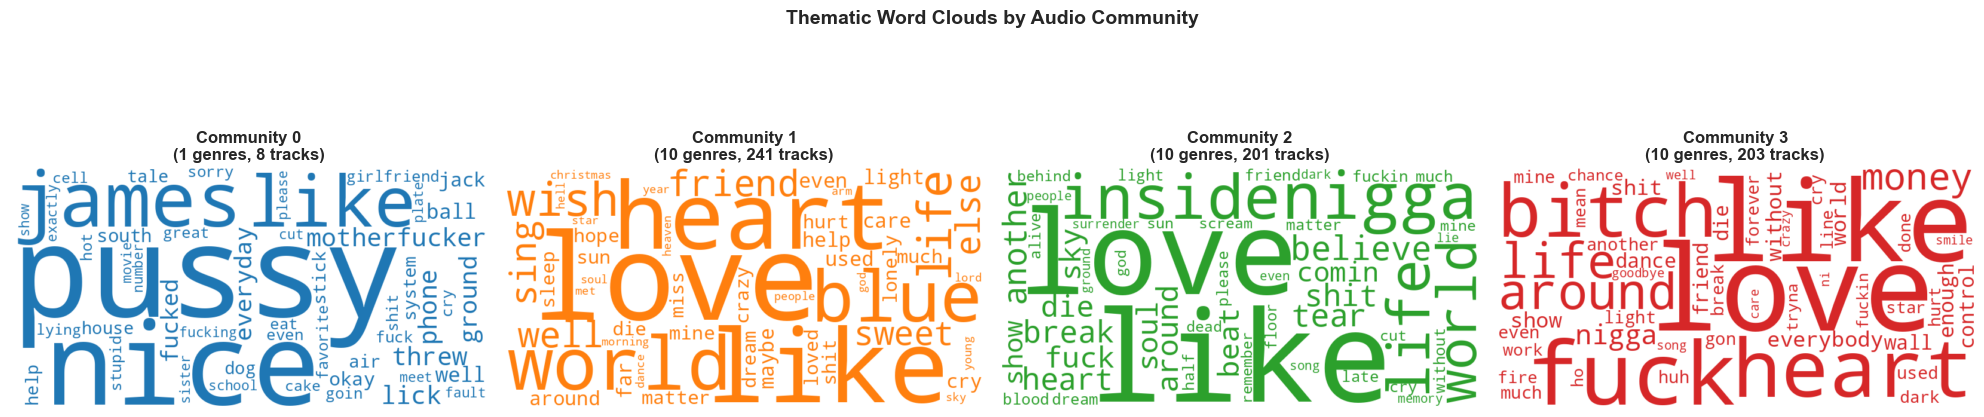


Saved to data/text_analysis_output/wordclouds_community.png


In [ ]:
# Generate community word clouds
fig, axes = plt.subplots(1, n_comms_wc, figsize=(5 * n_comms_wc, 5))

# Handle case of single community
if n_comms_wc == 1:
    axes = [axes]

for i, cid in enumerate(communities_in_data):
    # Get aggregated TF-IDF for community
    comm_vector = get_community_tfidf_aggregated(df_lyrics, tfidf_matrix, cid)
    
    if comm_vector is None:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'Community {cid}')
        axes[i].axis('off')
        continue
    
    # Get top terms
    top_terms = get_top_terms_from_vector(comm_vector, feature_names, top_n=WORDCLOUD_MAX_WORDS)
    
    # Get community color
    color = COMMUNITY_COLOR_HEX.get(cid, '#333333')
    
    # Create word cloud
    wc = create_wordcloud(top_terms, color, max_words=WORDCLOUD_MAX_WORDS)
    
    # Plot
    axes[i].imshow(wc, interpolation='bilinear')
    n_tracks = (df_lyrics['community_id'] == cid).sum()
    n_genres = df_lyrics[df_lyrics['community_id'] == cid]['genre'].nunique()
    axes[i].set_title(f'Community {cid}\n({n_genres} genres, {n_tracks} tracks)', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Thematic Word Clouds by Audio Community', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'wordclouds_community.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved to {OUTPUT_DIR / 'wordclouds_community.png'}")

In [ ]:
# Print top terms per community for reference
print("\n" + "="*60)
print("TOP TERMS PER AUDIO COMMUNITY")
print("="*60)

for cid in communities_in_data:
    comm_vector = get_community_tfidf_aggregated(df_lyrics, tfidf_matrix, cid)
    if comm_vector is None:
        continue
    
    top_terms = get_top_terms_from_vector(comm_vector, feature_names, top_n=15)
    terms_str = ", ".join([f"{term}" for term in top_terms.keys()])
    
    # Get genres in this community
    genres_in_comm = df_lyrics[df_lyrics['community_id'] == cid]['genre'].unique()
    
    print(f"\nCommunity {cid}:")
    print(f"  Genres: {', '.join(sorted(genres_in_comm))}")
    print(f"  Top terms: {terms_str}")


TOP TERMS PER AUDIO COMMUNITY

Community 0:
  Genres: comedy
  Top terms: pussy, nice, james, like, motherfucker, lick, threw, phone, ground, everyday, fucked, ball, well, jack, okay

Community 1:
  Genres: acoustic, bluegrass, disney, folk, guitar, honky-tonk, jazz, opera, sad, singer-songwriter
  Top terms: love, like, heart, world, blue, wish, life, friend, well, sing, else, sweet, light, used, maybe

Community 2:
  Genres: alt-rock, club, electronic, groove, hardcore, industrial, punk, punk-rock, trance, trip-hop
  Top terms: like, love, nigga, inside, life, world, believe, another, tear, break, shit, heart, around, die, fuck

Community 3:
  Genres: afrobeat, alternative, disco, emo, hip-hop, house, kids, party, r-n-b, synth-pop
  Top terms: love, like, fuck, heart, bitch, around, life, money, nigga, everybody, show, without, shit, world, enough


### 6.2 Top Terms by Community

A cleaner comparison showing the top 10 words per community side-by-side.

In [ ]:
# Top words comparison bar chart
TOP_N_WORDS = 10

fig, axes = plt.subplots(1, n_comms_wc, figsize=(5 * n_comms_wc, 6), sharey=False)
if n_comms_wc == 1:
    axes = [axes]

for i, cid in enumerate(communities_in_data):
    ax = axes[i]
    comm_vector = get_community_tfidf_aggregated(df_lyrics, tfidf_matrix, cid)
    
    if comm_vector is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(f'Community {cid}')
        continue
    
    top_terms = get_top_terms_from_vector(comm_vector, feature_names, top_n=TOP_N_WORDS)
    words = list(top_terms.keys())[::-1]
    weights = list(top_terms.values())[::-1]
    
    color = COMMUNITY_COLOR_MAP[cid]
    ax.barh(words, weights, color=color, alpha=0.8)
    
    genres_in_comm = df_lyrics[df_lyrics['community_id'] == cid]['genre'].unique()
    genre_str = ', '.join(sorted(genres_in_comm)[:3]) + ('...' if len(genres_in_comm) > 3 else '')
    
    ax.set_xlabel('TF-IDF Weight', fontsize=10)
    ax.set_title(f'Community {cid}\n({genre_str})', fontsize=11, fontweight='bold')

plt.suptitle(f'Top {TOP_N_WORDS} Words by Audio Community', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_words_by_community.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {OUTPUT_DIR / 'top_words_by_community.png'}")

## 7. Sentiment Analysis

We analyze the emotional tone of lyrics using VADER sentiment analysis.

**What to look for:**
- Do communities differ in overall sentiment (positive vs. negative)?
- Which genres are most positive/negative?
- Does sentiment align with genre stereotypes (e.g., is metal more negative)?

### 7.1 Sentiment Analysis with VADER

In [ ]:
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()
print("VADER sentiment analyzer loaded")

In [ ]:
# Compute sentiment for all lyrics (using original lyrics, not preprocessed)
def get_sentiment(text):
	"""Get VADER compound sentiment score for text."""
	if pd.isna(text) or not text:
		return 0.0
	scores = sia.polarity_scores(text)
	return scores['compound']

# Apply to all lyrics
df_lyrics['sentiment'] = df_lyrics['lyrics'].apply(get_sentiment)

print(f"Sentiment scores computed for {len(df_lyrics)} tracks.")
print(f"\nSentiment distribution:")
print(f"  Mean: {df_lyrics['sentiment'].mean():.3f}")
print(f"  Std:  {df_lyrics['sentiment'].std():.3f}")
print(f"  Min:  {df_lyrics['sentiment'].min():.3f}")
print(f"  Max:  {df_lyrics['sentiment'].max():.3f}")

# Show examples of positive and negative songs
print("\nMost positive songs:")
for _, row in df_lyrics.nlargest(3, 'sentiment').iterrows():
	print(f"  {row['sentiment']:.3f} - {row['track_name']} ({row['genre']})")

print("\nMost negative songs:")
for _, row in df_lyrics.nsmallest(3, 'sentiment').iterrows():
	print(f"  {row['sentiment']:.3f} - {row['track_name']} ({row['genre']})")

Sentiment scores computed for 653 tracks.

Sentiment distribution:
  Mean: 0.172
  Std:  0.871
  Min:  -1.000
  Max:  1.000

Most positive songs:
  1.000 - Love Me Now (feat. Zoe Wees) (house)
  1.000 - Young And In Love (acoustic)
  1.000 - Doses (sad)

Most negative songs:
  -1.000 - It's On (hardcore)
  -0.999 - Not Like That (sad)
  -0.999 - Brooklyn Zoo (alternative)


### 7.2 Sentiment by Community

Box plots show the distribution of sentiment scores within each audio community.

/var/folders/vq/hbwc6_v92sg0d1qr62bc4_800000gn/T/ipykernel_83014/3586999515.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


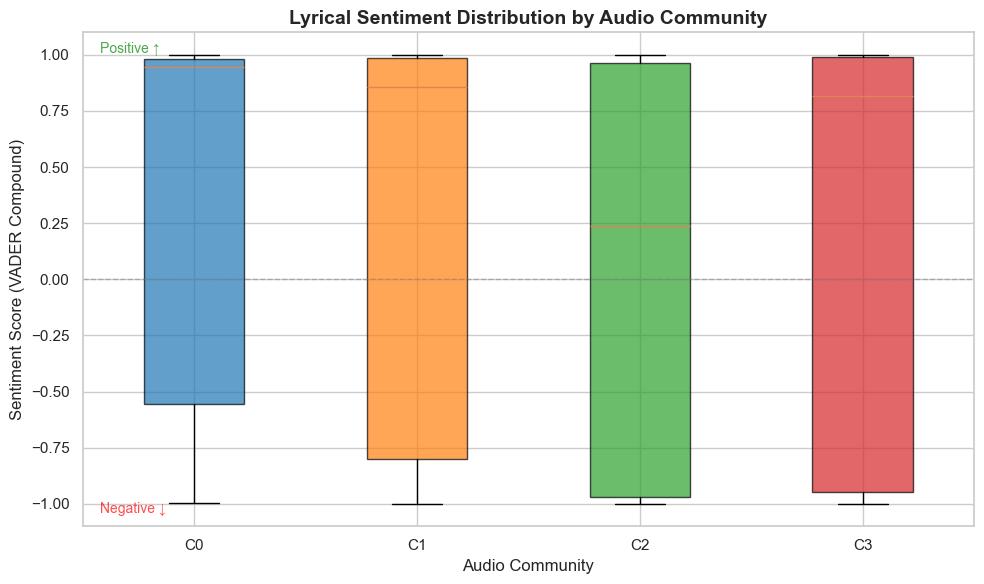


Saved to data/text_analysis_output/sentiment_by_community.png

Sentiment by community (mean):
  Community 0: mean=0.311, std=0.927
    Genres: comedy
  Community 1: mean=0.289, std=0.835
    Genres: acoustic, bluegrass, disney, folk, guitar...
  Community 2: mean=0.021, std=0.877
    Genres: alt-rock, club, electronic, groove, hardcore...
  Community 3: mean=0.178, std=0.889
    Genres: afrobeat, alternative, disco, emo, hip-hop...


In [ ]:
# Create box plot of sentiment by community
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for plotting
communities_sorted = sorted(df_lyrics['community_id'].unique())

# Create box plot with community colors
bp = ax.boxplot(
	[df_lyrics[df_lyrics['community_id'] == cid]['sentiment'].values for cid in communities_sorted],
	labels=[f'C{cid}' for cid in communities_sorted],
	patch_artist=True
)

# Color boxes by community
for i, cid in enumerate(communities_sorted):
	bp['boxes'][i].set_facecolor(COMMUNITY_COLOR_MAP[cid])
	bp['boxes'][i].set_alpha(0.7)

# Add horizontal line at 0 (neutral)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Labels
ax.set_xlabel('Audio Community', fontsize=12)
ax.set_ylabel('Sentiment Score (VADER Compound)', fontsize=12)
ax.set_title('Lyrical Sentiment Distribution by Audio Community', fontsize=14, fontweight='bold')

# Add text annotation for interpretation
ax.text(0.02, 0.98, 'Positive ↑', transform=ax.transAxes, fontsize=10, 
		verticalalignment='top', color='green', alpha=0.7)
ax.text(0.02, 0.02, 'Negative ↓', transform=ax.transAxes, fontsize=10, 
		verticalalignment='bottom', color='red', alpha=0.7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_by_community.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved to {OUTPUT_DIR / 'sentiment_by_community.png'}")

# Print summary stats
print("\nSentiment by community (mean):")
for cid in communities_sorted:
	comm_sentiment = df_lyrics[df_lyrics['community_id'] == cid]['sentiment']
	genres_in_comm = df_lyrics[df_lyrics['community_id'] == cid]['genre'].unique()
	print(f"  Community {cid}: mean={comm_sentiment.mean():.3f}, std={comm_sentiment.std():.3f}")
	print(f"    Genres: {', '.join(sorted(genres_in_comm)[:5])}{'...' if len(genres_in_comm) > 5 else ''}")

### 7.2 Sentiment by Genre

Bar chart showing mean sentiment for each genre we sampled, sorted from most negative to most positive.

In [ ]:
# Compute mean sentiment per genre
genre_sentiments = []

for genre in genres_with_lyrics:
    genre_df = df_lyrics[df_lyrics["genre"] == genre]
    if len(genre_df) > 0:
        genre_sentiments.append(
            {
                "genre": genre,
                "sentiment_mean": genre_df["sentiment"].mean(),
                "sentiment_std": genre_df["sentiment"].std(),
                "n_tracks": len(genre_df),
                "community_id": comm_map_audio.get(genre, 0),
            }
        )

df_genre_sentiment = pd.DataFrame(genre_sentiments)
df_genre_sentiment = df_genre_sentiment.sort_values("sentiment_mean", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, max(6, len(df_genre_sentiment) * 0.4)))

bar_colors = [COMMUNITY_COLOR_MAP[cid] for cid in df_genre_sentiment["community_id"]]

bars = ax.barh(
    df_genre_sentiment["genre"],
    df_genre_sentiment["sentiment_mean"],
    xerr=df_genre_sentiment["sentiment_std"],
    color=bar_colors,
    alpha=0.8,
    capsize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Mean Sentiment Score", fontsize=12)
ax.set_ylabel("Genre", fontsize=12)
ax.set_title(
    "Lyrical Sentiment by Genre\n(Color = Audio Community)",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_by_genre.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to {OUTPUT_DIR / 'sentiment_by_genre.png'}")

### 7.3 Top Words Comparison

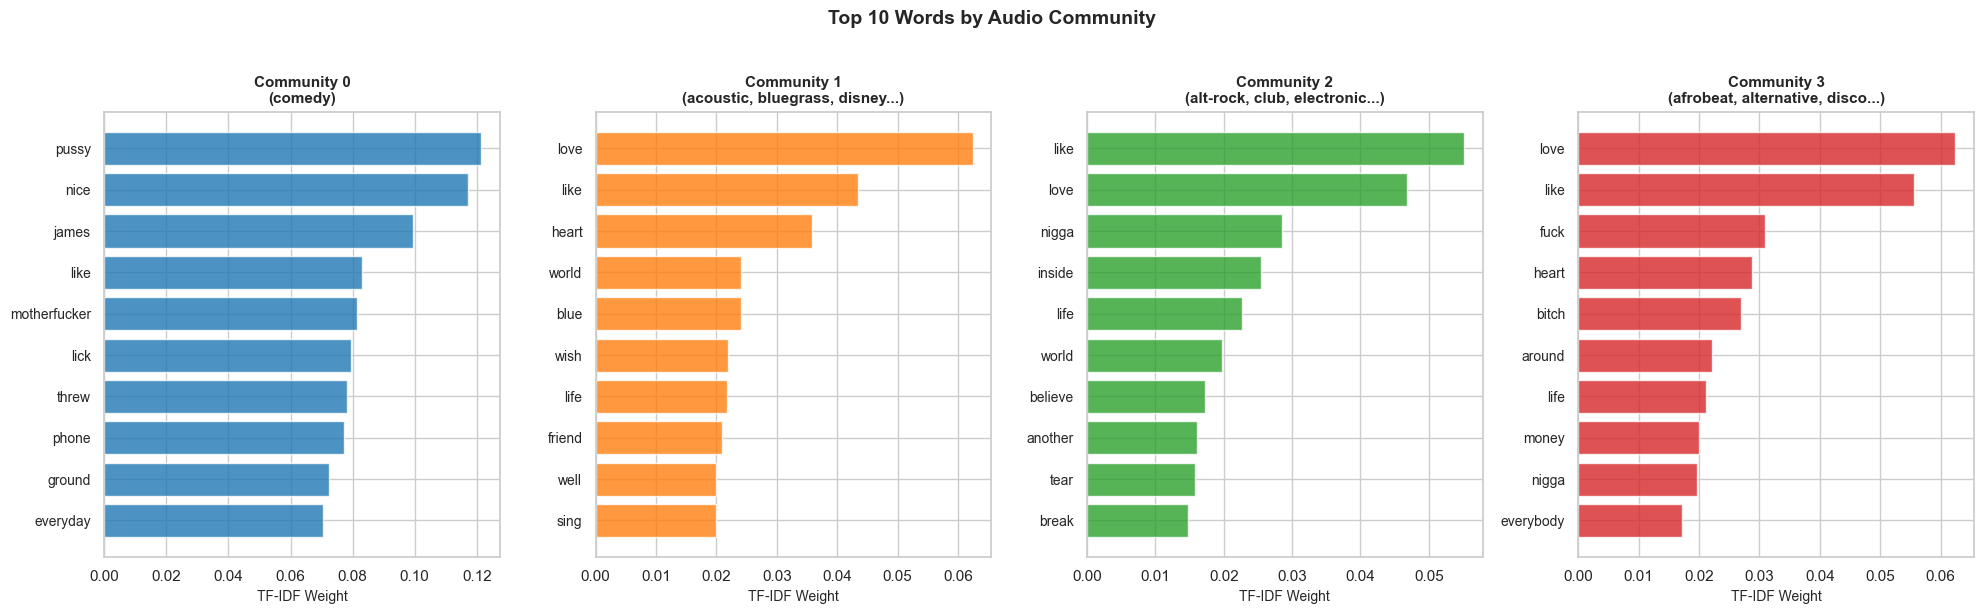


Saved to data/text_analysis_output/top_words_by_community.png


In [ ]:
# Create a side-by-side bar chart showing top 10 words per community
TOP_N_WORDS = 10

fig, axes = plt.subplots(1, n_comms_wc, figsize=(5 * n_comms_wc, 6), sharey=False)

if n_comms_wc == 1:
    axes = [axes]

for i, cid in enumerate(communities_in_data):
    ax = axes[i]
    
    # Get aggregated TF-IDF for community
    comm_vector = get_community_tfidf_aggregated(df_lyrics, tfidf_matrix, cid)
    
    if comm_vector is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(f'Community {cid}')
        continue
    
    # Get top terms
    top_terms = get_top_terms_from_vector(comm_vector, feature_names, top_n=TOP_N_WORDS)
    
    # Create horizontal bar chart
    words = list(top_terms.keys())
    weights = list(top_terms.values())
    
    # Reverse for top-to-bottom ordering
    words = words[::-1]
    weights = weights[::-1]
    
    color = COMMUNITY_COLOR_MAP[cid]
    ax.barh(words, weights, color=color, alpha=0.8)
    
    # Get genres in community for subtitle
    genres_in_comm = df_lyrics[df_lyrics['community_id'] == cid]['genre'].unique()
    genre_str = ', '.join(sorted(genres_in_comm)[:3]) + ('...' if len(genres_in_comm) > 3 else '')
    
    ax.set_xlabel('TF-IDF Weight', fontsize=10)
    ax.set_title(f'Community {cid}\n({genre_str})', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)

plt.suptitle(f'Top {TOP_N_WORDS} Words by Audio Community', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_words_by_community.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved to {OUTPUT_DIR / 'top_words_by_community.png'}")

## 8. Summary

Overview of the text analysis pipeline and key outputs.

In [ ]:
print("="*80)
print("TEXT ANALYSIS SUMMARY")
print("="*80)

print(f"\n CONFIGURATION:")
print(f"   - Random seed: {RANDOM_SEED}")
print(f"   - Genres per community: {N_GENRES_PER_COMMUNITY} (random)")
print(f"   - Songs per genre: {SONGS_PER_GENRE} (random)")
print(f"   - Min tracks threshold: {MIN_TRACKS_PER_GENRE}")
print(f"   - Max instrumentalness: {MAX_INSTRUMENTALNESS}")

print(f"\n DATA:")
print(f"   - Total genres in dataset: {len(genres_all)}")
print(f"   - Genres excluded (all filters): {len(df_filtered)}")
print(f"   - Genres sampled for lyrics: {len(genres_with_lyrics)}")
print(f"   - Total tracks with lyrics: {len(df_lyrics)}")
print(f"   - TF-IDF vocabulary size: {len(feature_names)} (unigrams only)")

print(f"\n STOPWORDS:")
print(f"   - NLTK stopwords: {len(NLTK_STOPWORDS)}")
print(f"   - Custom stopwords: {len(CUSTOM_STOPWORDS)}")
print(f"   - Common themes removed: {THEMES_TO_REMOVE if THEMES_TO_REMOVE else 'None'}")
print(f"   - Total stopwords: {len(ALL_STOPWORDS)}")

print(f"\n AUDIO COMMUNITIES:")
print(f"   - Number of communities: {len(genre_comms)}")
print(f"   - Modularity Q: {Q_audio:.4f}")

print(f"\n WORD CLOUDS:")
print(f"   - Community word clouds: {n_comms_wc}")
print(f"   - Archetypal genre word clouds: {len(available_archetypal)}")

if VADER_AVAILABLE:
    print(f"\n SENTIMENT ANALYSIS:")
    print(f"   - Overall mean sentiment: {df_lyrics['sentiment'].mean():.3f}")
    print(f"   - Sentiment range: [{df_lyrics['sentiment'].min():.3f}, {df_lyrics['sentiment'].max():.3f}]")

print(f"\n OUTPUTS:")
print(f"   - Community word clouds: {OUTPUT_DIR / 'wordclouds_community.png'}")
print(f"   - Genre word clouds: {OUTPUT_DIR / 'wordclouds_genre_archetypal.png'}")
print(f"   - Sentiment by community: {OUTPUT_DIR / 'sentiment_by_community.png'}")
print(f"   - Sentiment by genre: {OUTPUT_DIR / 'sentiment_by_genre.png'}")
print(f"   - Top words comparison: {OUTPUT_DIR / 'top_words_by_community.png'}")
print(f"   - Lyrics data: {OUTPUT_DIR / 'all_lyrics.csv'}")
print(f"   - Top terms: {OUTPUT_DIR / 'genre_top_tfidf_terms.csv'}")

TEXT ANALYSIS SUMMARY

 CONFIGURATION:
   - Random seed: 42
   - Genres per community: 10 (random)
   - Songs per genre: 50 (random)
   - Min tracks threshold: 100
   - Max instrumentalness: 0.5

 DATA:
   - Total genres in dataset: 114
   - Genres excluded (all filters): 39
   - Genres sampled for lyrics: 31
   - Total tracks with lyrics: 653
   - TF-IDF vocabulary size: 1237 (unigrams only)

 STOPWORDS:
   - NLTK stopwords: 198
   - Custom stopwords: 348
   - Common themes removed: None
   - Total stopwords: 544

 AUDIO COMMUNITIES:
   - Number of communities: 4
   - Modularity Q: 0.4209

 WORD CLOUDS:
   - Community word clouds: 4
   - Archetypal genre word clouds: 6

 SENTIMENT ANALYSIS:
   - Overall mean sentiment: 0.172
   - Sentiment range: [-1.000, 1.000]

 OUTPUTS:
   - Community word clouds: data/text_analysis_output/wordclouds_community.png
   - Genre word clouds: data/text_analysis_output/wordclouds_genre_archetypal.png
   - Sentiment by community: data/text_analysis_output

In [ ]:
# Save top terms per genre for reference
top_terms_df = []
for i, genre in enumerate(genres_with_lyrics):
    top_terms = get_top_terms_for_genre(i, top_n=15)
    comm_id = comm_map_audio.get(genre, -1)
    for term, weight in top_terms:
        top_terms_df.append({
            'genre': genre,
            'community_id': comm_id,
            'term': term,
            'tfidf_weight': weight
        })

pd.DataFrame(top_terms_df).to_csv(OUTPUT_DIR / 'genre_top_tfidf_terms.csv', index=False)
print(f"Saved top terms per genre to {OUTPUT_DIR / 'genre_top_tfidf_terms.csv'}")

Saved top terms per genre to data/text_analysis_output/genre_top_tfidf_terms.csv


In [ ]:
# Save sentiment data if available
if VADER_AVAILABLE:
    # Save full lyrics with sentiment
    df_lyrics.to_csv(OUTPUT_DIR / 'all_lyrics_with_sentiment.csv', index=False)
    print(f"Saved lyrics with sentiment to {OUTPUT_DIR / 'all_lyrics_with_sentiment.csv'}")
    
    # Save genre-level sentiment summary
    genre_sentiment_summary = df_lyrics.groupby('genre').agg({
        'sentiment': ['mean', 'std', 'min', 'max', 'count'],
        'community_id': 'first'
    }).round(3)
    genre_sentiment_summary.columns = ['sentiment_mean', 'sentiment_std', 'sentiment_min', 
                                        'sentiment_max', 'n_tracks', 'community_id']
    genre_sentiment_summary = genre_sentiment_summary.sort_values('sentiment_mean', ascending=False)
    genre_sentiment_summary.to_csv(OUTPUT_DIR / 'genre_sentiment_summary.csv')
    print(f"Saved genre sentiment summary to {OUTPUT_DIR / 'genre_sentiment_summary.csv'}")

Saved lyrics with sentiment to data/text_analysis_output/all_lyrics_with_sentiment.csv
Saved genre sentiment summary to data/text_analysis_output/genre_sentiment_summary.csv


# References

- NetworkX (Spring, Kamada-Kawai, Circular, Random), for standard layouts for the visualizations
- Fruchterman, T. M. J., & Reingold, E. M. (1991). Graph drawing by force-directed placement. Software: Practice and Experience, 21(11), 1129–1164, for Spring layout
- Kamada, T., & Kawai, S. (1989). An algorithm for drawing general undirected graphs. Information Processing Letters, 31(1), 7–15, for Kamada-Kawai layout
- Newman, M. E. J. (2010). Networks: An Introduction. Oxford University Press. (Ch. 7 covers visualization basics), for general background on network visualizations
- Garlaschelli, D., & Loffredo, M. I. (2004). Patterns of link reciprocity in directed networks. Physical Review Letters, 93(26), 268701, for reciprocity analysis.
- Capocci, A., Servedio, V. D. P., Colaiori, F., Buriol, L. S., Donato, D., Leonardi, S., & Caldarelli, G. (2006). Preferential attachment in the growth of social networks: The internet encyclopedia Wikipedia. Physical Review E, 74(3), 036116, for preferential attachment and Wikipedia networks.
- Jackson, M. O. (2008). Social and economic networks. Princeton University Press, for general theory of network structure and dynamics.
